# Phân Tích Chuỗi Thời Gian Cổ Phiếu VIC (Vingroup)
## Pipeline 7 cấp độ: AR → MA → ARIMA → Optuna → Prophet → Ensemble → Log-Returns → GARCH → ARIMAX

**Cấu trúc dữ liệu:**
- Tổng: 2 năm dữ liệu giao dịch
- **Test**: 10 ngày giao dịch cuối cùng (có giá thực tế để so sánh)
- **Val**: 10 ngày giao dịch liền trước test
- **Train**: Toàn bộ dữ liệu còn lại (~2 năm trừ 20 ngày)

In [1]:
!pip install yfinance statsmodels scikit-learn matplotlib pandas numpy seaborn scipy optuna prophet arch -q

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats
import yfinance as yf
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
from prophet import Prophet
from arch import arch_model
from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})

COLORS = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#00BCD4','#795548','#E91E63','#009688']

# ── Constants ──────────────────────────────────────────────────────────
TICKER    = 'VIC.VN'
PERIOD    = '2y'
TEST_DAYS = 10          # 10 ngày giao dịch cuối = test
VAL_DAYS  = 10          # 10 ngày giao dịch trước test = val
P_MAX     = 4
Q_MAX     = 4
FORECAST  = 10          # dự đoán tương lai 10 ngày

def fmt_vnd(x): return f'{x:,.0f}'
def mape_fn(y_true, y_pred): return np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100
def metrics_fn(y_true, y_pred):
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mape_fn(y_true, y_pred)
    }

def print_comparison_table(test_series, pred_series, model_name):
    """In bảng so sánh giá thực tế vs dự đoán"""
    print(f'\n{"="*75}')
    print(f'  [{model_name}] BẢNG SO SÁNH GIÁ THỰC TẾ vs DỰ ĐOÁN')
    print(f'{"="*75}')
    print(f'  {"Ngày":<12} {"Thực tế (VND)":>14} {"Dự đoán (VND)":>14} {"Chênh lệch":>12} {"Sai số %":>9}')
    print(f'  {"-"*12} {"-"*14} {"-"*14} {"-"*12} {"-"*9}')
    errors = []
    for date, actual, pred in zip(test_series.index, test_series.values, pred_series.values):
        diff = pred - actual
        pct  = diff / actual * 100
        errors.append(abs(pct))
        sign = '+' if diff >= 0 else ''
        print(f'  {str(date.date()):<12} {fmt_vnd(actual):>14} {fmt_vnd(pred):>14} {sign+fmt_vnd(diff):>12} {sign+f"{pct:.2f}%":>9}')
    m = metrics_fn(test_series.values, pred_series.values)
    print(f'{"─"*75}')
    print(f'  MAE={fmt_vnd(m["MAE"])} VND  |  RMSE={fmt_vnd(m["RMSE"])} VND  |  MAPE={m["MAPE"]:.2f}%')
    print(f'{"="*75}\n')
    return m

print('✓ Import và cấu hình hoàn tất')
print(f'  TICKER={TICKER}, PERIOD={PERIOD}, TEST_DAYS={TEST_DAYS}, VAL_DAYS={VAL_DAYS}')

Importing plotly failed. Interactive plots will not work.


✓ Import và cấu hình hoàn tất
  TICKER=VIC.VN, PERIOD=2y, TEST_DAYS=10, VAL_DAYS=10


## 1. Tải Dữ Liệu & Phân Chia Train/Val/Test

In [3]:
print(f'Đang tải dữ liệu {TICKER} ({PERIOD})...')
raw = yf.download(TICKER, period=PERIOD, auto_adjust=True, progress=False)
raw = raw.dropna()
df  = raw['Close'].squeeze()

# ── Phân chia dữ liệu ──────────────────────────────────────────────────
test  = df.iloc[-TEST_DAYS:]
val   = df.iloc[-(TEST_DAYS + VAL_DAYS):-TEST_DAYS]
train = df.iloc[:-(TEST_DAYS + VAL_DAYS)]

print(f'\n{"═"*65}')
print(f'  PHÂN CHIA DỮ LIỆU {TICKER}')
print(f'{"═"*65}')
print(f'  Tổng:  {len(df):>4} ngày  ({df.index[0].date()} → {df.index[-1].date()})')
print(f'  Train: {len(train):>4} ngày  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'  Val:   {len(val):>4} ngày  ({val.index[0].date()} → {val.index[-1].date()})')
print(f'  Test:  {len(test):>4} ngày  ({test.index[0].date()} → {test.index[-1].date()})')
print(f'{"═"*65}')
print(f'  Tỷ lệ: Train={len(train)/len(df)*100:.1f}%  Val={len(val)/len(df)*100:.1f}%  Test={len(test)/len(df)*100:.1f}%')
print(f'{"═"*65}')
print(f'\n  Giá hiện tại (test cuối): {fmt_vnd(test.iloc[-1])} VND')
print(f'  Giá TB train:             {fmt_vnd(train.mean())} VND')
print(f'  Max 2 năm:                {fmt_vnd(df.max())} VND')
print(f'  Min 2 năm:                {fmt_vnd(df.min())} VND')

# ── Bảng giá TEST (thực tế) ────────────────────────────────────────────
print(f'\n{"─"*45}')
print(f'  GIÁ THỰC TẾ TRONG GIAI ĐOẠN TEST')
print(f'{"─"*45}')
for d, v in zip(test.index, test.values):
    print(f'  {str(d.date()):<12}  {fmt_vnd(v):>12} VND')
print(f'{"─"*45}')

Đang tải dữ liệu VIC.VN (2y)...

═════════════════════════════════════════════════════════════════
  PHÂN CHIA DỮ LIỆU VIC.VN
═════════════════════════════════════════════════════════════════
  Tổng:   523 ngày  (2024-06-17 → 2026-06-17)
  Train:  503 ngày  (2024-06-17 → 2026-05-20)
  Val:     10 ngày  (2026-05-21 → 2026-06-03)
  Test:    10 ngày  (2026-06-04 → 2026-06-17)
═════════════════════════════════════════════════════════════════
  Tỷ lệ: Train=96.2%  Val=1.9%  Test=1.9%
═════════════════════════════════════════════════════════════════

  Giá hiện tại (test cuối): 190,900 VND
  Giá TB train:             70,909 VND
  Max 2 năm:                229,800 VND
  Min 2 năm:                19,950 VND

─────────────────────────────────────────────
  GIÁ THỰC TẾ TRONG GIAI ĐOẠN TEST
─────────────────────────────────────────────
  2026-06-04         200,200 VND
  2026-06-05         207,000 VND
  2026-06-08         195,000 VND
  2026-06-09         193,200 VND
  2026-06-10         196,000 VN

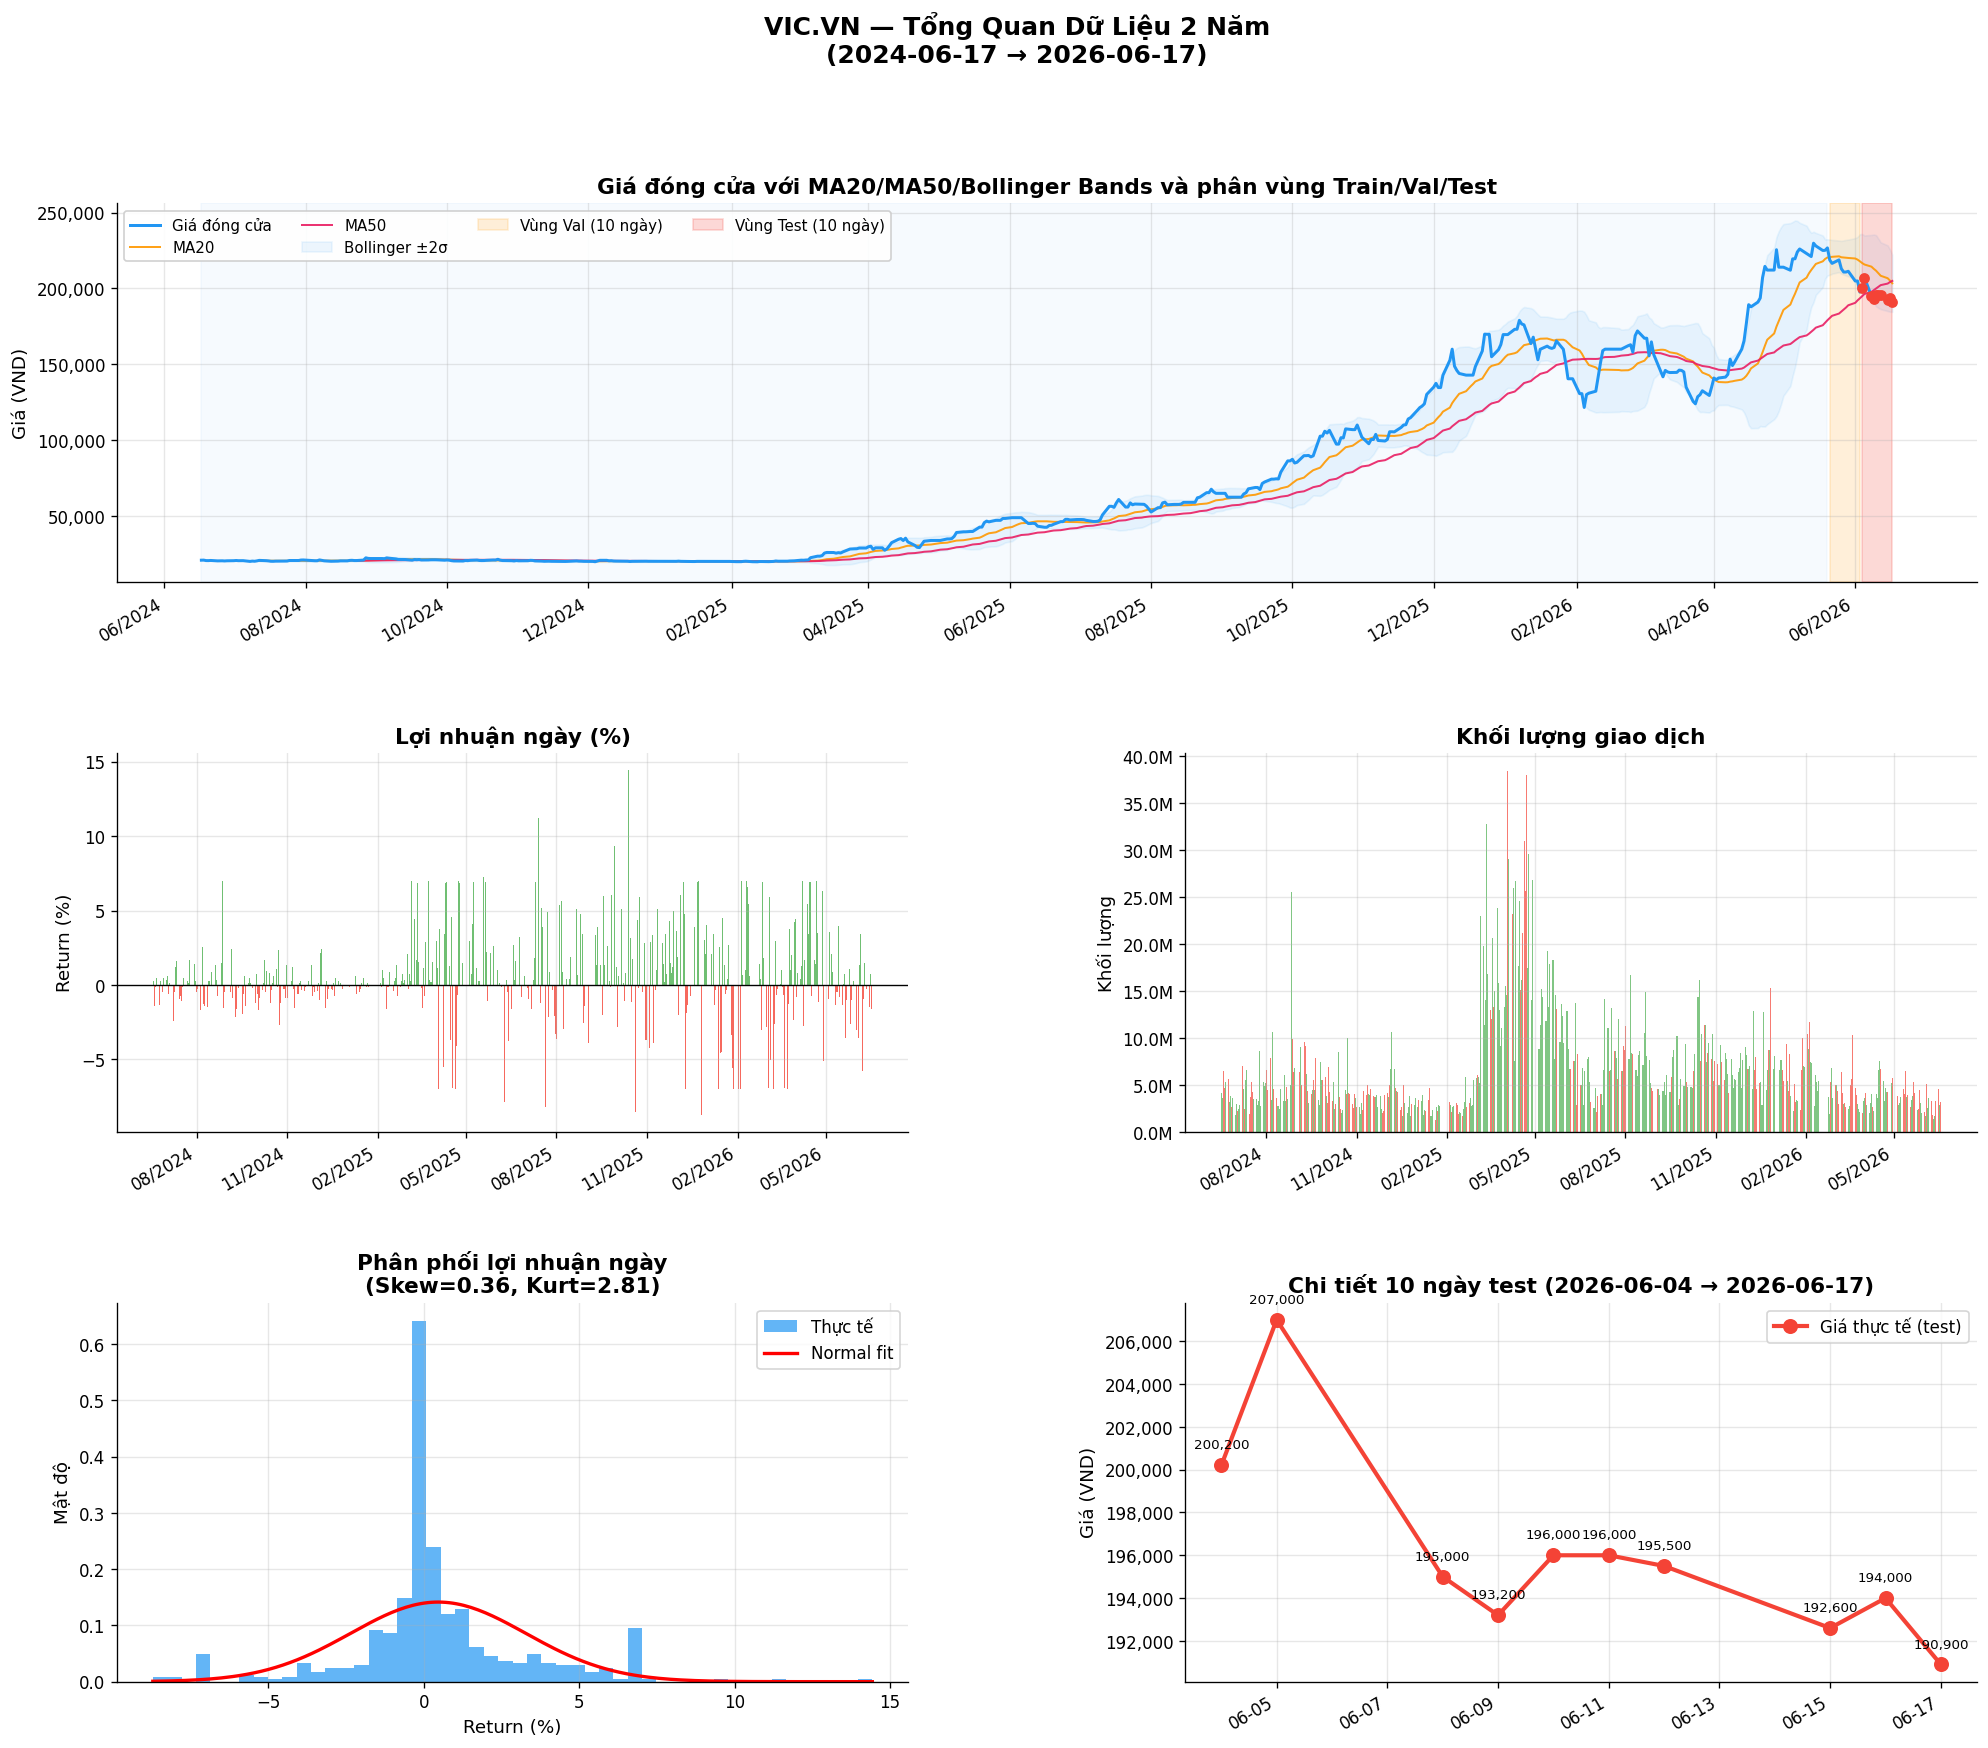

In [4]:
# ── Visualization: Phân chia + Technical Indicators ─────────────────────
ma20 = df.rolling(20).mean()
ma50 = df.rolling(50).mean()
std20 = df.rolling(20).std()
bb_upper = ma20 + 2*std20
bb_lower = ma20 - 2*std20
daily_ret = df.pct_change() * 100

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(f'VIC.VN — Tổng Quan Dữ Liệu 2 Năm\n({df.index[0].date()} → {df.index[-1].date()})',
             fontsize=15, fontweight='bold', y=0.98)

# Panel 1: Giá + MA + BB + vùng split
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, df,       color='#2196F3', lw=1.8, label='Giá đóng cửa', zorder=5)
ax1.plot(df.index, ma20,     color='#FF9800', lw=1.2, alpha=0.9, label='MA20')
ax1.plot(df.index, ma50,     color='#E91E63', lw=1.2, alpha=0.9, label='MA50')
ax1.fill_between(df.index, bb_lower, bb_upper, alpha=0.08, color='#2196F3', label='Bollinger ±2σ')
ax1.axvspan(train.index[0],  train.index[-1], alpha=0.04, color='#2196F3')
ax1.axvspan(val.index[0],    val.index[-1],   alpha=0.15, color='#FF9800', label=f'Vùng Val ({VAL_DAYS} ngày)')
ax1.axvspan(test.index[0],   test.index[-1],  alpha=0.20, color='#F44336', label=f'Vùng Test ({TEST_DAYS} ngày)')
for d, v in zip(test.index, test.values):
    ax1.scatter(d, v, color='#F44336', s=30, zorder=6)
ax1.set_ylabel('Giá (VND)', fontsize=11)
ax1.set_title('Giá đóng cửa với MA20/MA50/Bollinger Bands và phân vùng Train/Val/Test', fontweight='bold')
ax1.legend(ncol=4, fontsize=9, loc='upper left', framealpha=0.9)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Panel 2: Daily Returns
ax2 = fig.add_subplot(gs[1, 0])
colors_r = ['#4CAF50' if r >= 0 else '#F44336' for r in daily_ret.fillna(0)]
ax2.bar(df.index, daily_ret, color=colors_r, width=1.0, alpha=0.8)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Return (%)')
ax2.set_title('Lợi nhuận ngày (%)', fontweight='bold')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Panel 3: Volume
ax3 = fig.add_subplot(gs[1, 1])
vol_col = ['#4CAF50' if i == 0 or df.iloc[i] >= df.iloc[i-1] else '#F44336' for i in range(len(df))]
ax3.bar(raw.index, raw['Volume'].squeeze(), color=vol_col, width=1.0, alpha=0.7)
ax3.set_ylabel('Khối lượng')
ax3.set_title('Khối lượng giao dịch', fontweight='bold')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x/1e6:.1f}M'))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Panel 4: Distribution Returns
ax4 = fig.add_subplot(gs[2, 0])
ret_clean = daily_ret.dropna()
ax4.hist(ret_clean, bins=50, color='#2196F3', alpha=0.7, density=True, label='Thực tế')
xr = np.linspace(ret_clean.min(), ret_clean.max(), 200)
ax4.plot(xr, stats.norm.pdf(xr, ret_clean.mean(), ret_clean.std()), 'r-', lw=2, label='Normal fit')
ax4.set_xlabel('Return (%)')
ax4.set_ylabel('Mật độ')
ax4.set_title(f'Phân phối lợi nhuận ngày\n(Skew={ret_clean.skew():.2f}, Kurt={ret_clean.kurt():.2f})', fontweight='bold')
ax4.legend()

# Panel 5: Giá trong 10 ngày test
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(test.index, test.values, 'o-', color='#F44336', lw=2.5, ms=8, label='Giá thực tế (test)')
for d, v in zip(test.index, test.values):
    ax5.annotate(fmt_vnd(v), (d, v), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)
ax5.set_title(f'Chi tiết 10 ngày test ({test.index[0].date()} → {test.index[-1].date()})', fontweight='bold')
ax5.set_ylabel('Giá (VND)')
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax5.legend()

plt.savefig('01_data_overview.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Kiểm Tra Dừng (Stationarity)

Kiểm định ADF (Augmented Dickey-Fuller):
───────────────────────────────────────────────────────
  ADF [Giá gốc]: stat=0.1359, p=0.9684 → ✗ KHÔNG
  ADF [Sai phân bậc 1]: stat=-5.4597, p=0.0000 → ✓ CÓ
───────────────────────────────────────────────────────
  → Bậc tích hợp d = 1


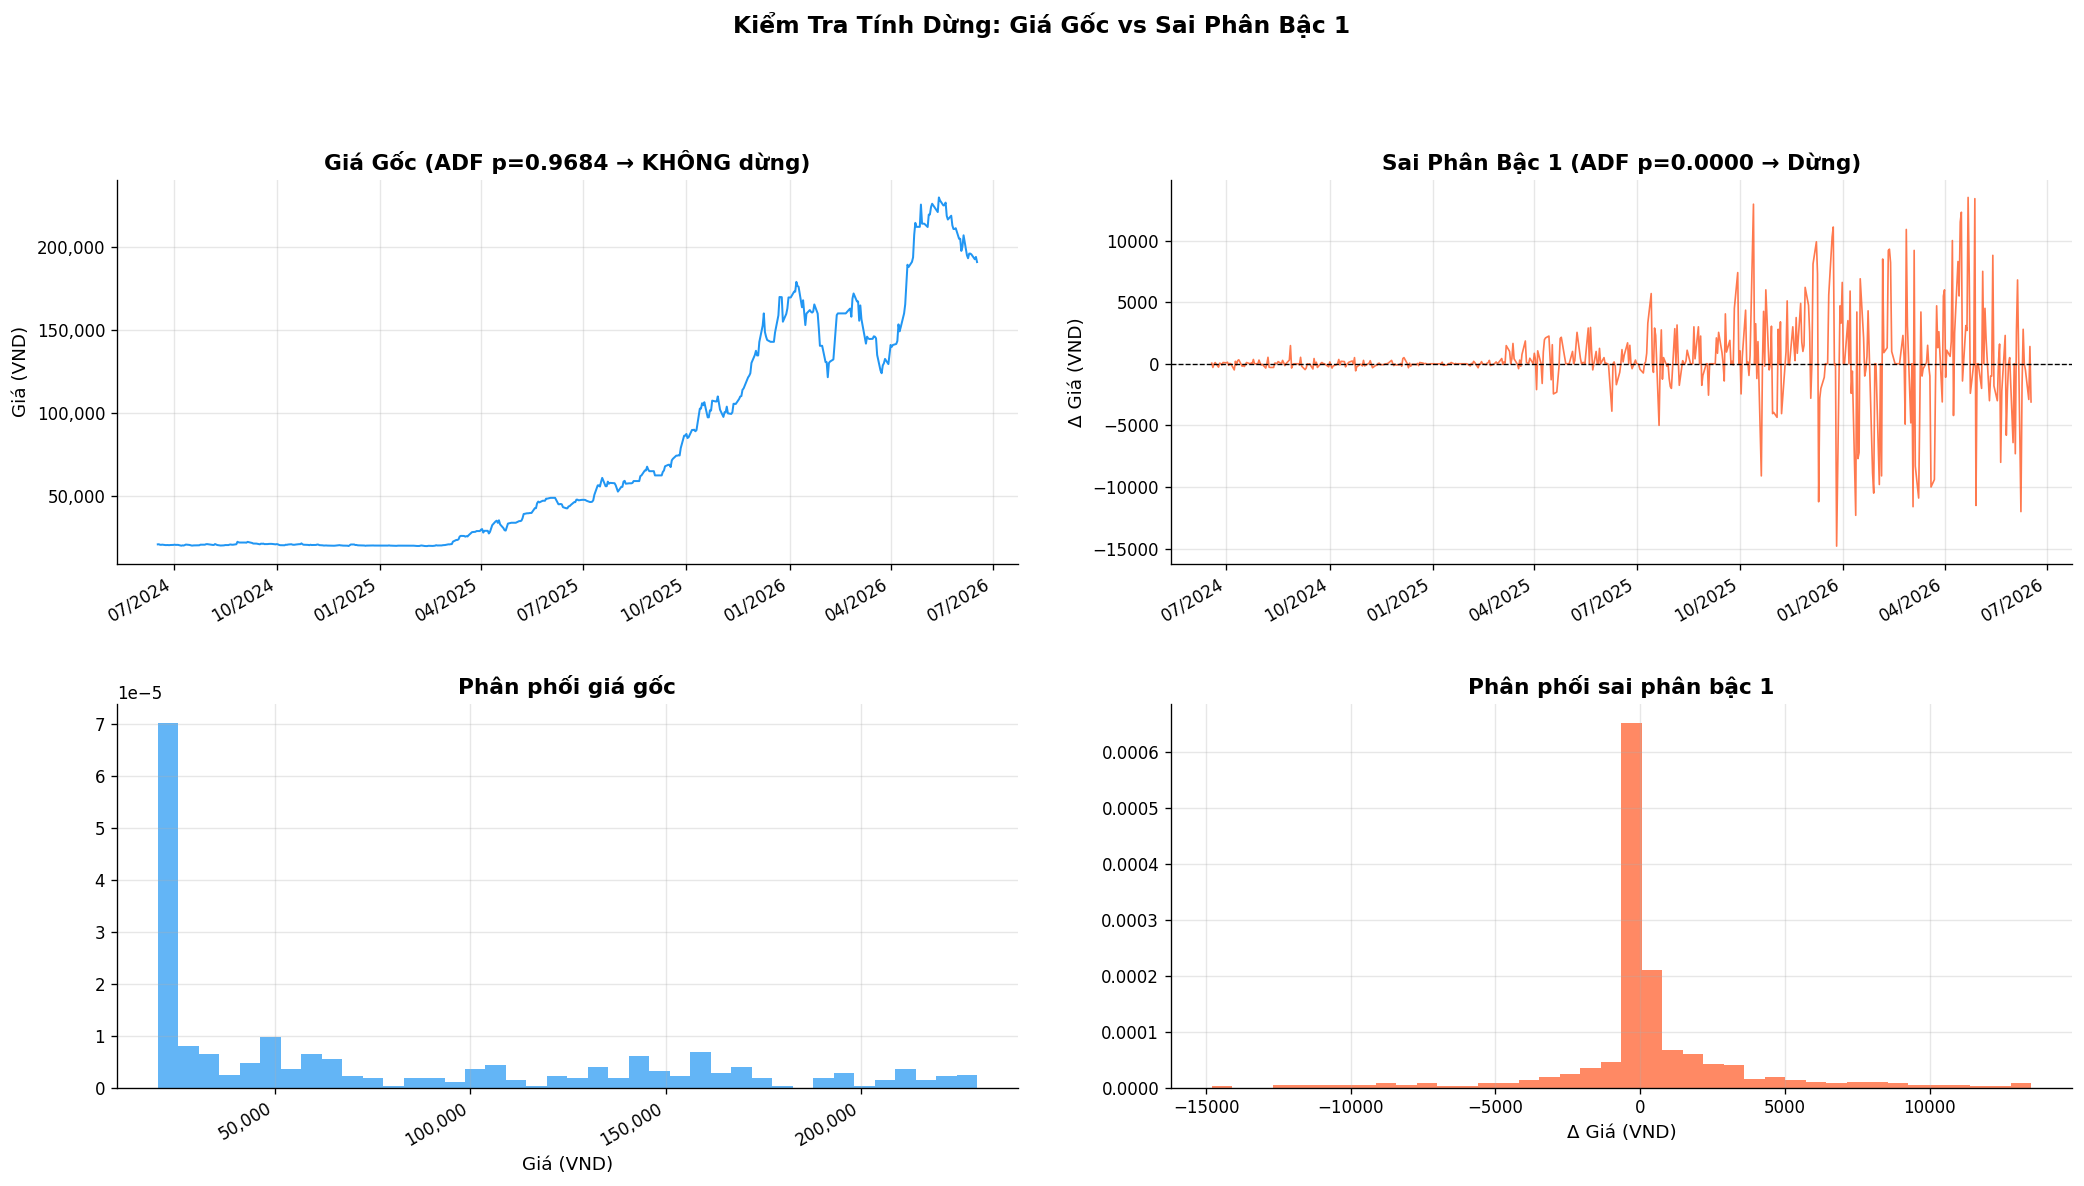

In [5]:
def adf_report(series, name):
    r = adfuller(series.dropna(), autolag='AIC')
    result = {'Thống kê ADF': r[0], 'p-value': r[1],
              'Bác bỏ H0 (chuỗi dừng)': '✓ CÓ' if r[1] < 0.05 else '✗ KHÔNG'}
    for k, v in r[4].items():
        result[f'Critical {k}'] = v
    print(f'  ADF [{name}]: stat={r[0]:.4f}, p={r[1]:.4f} → {result["Bác bỏ H0 (chuỗi dừng)"]}')
    return r[1] < 0.05

df_d1 = df.diff().dropna()

print('Kiểm định ADF (Augmented Dickey-Fuller):')
print(f'{"─"*55}')
s0 = adf_report(df,   'Giá gốc')
s1 = adf_report(df_d1,'Sai phân bậc 1')
print(f'{"─"*55}')
d_order = 0 if s0 else (1 if s1 else 2)
print(f'  → Bậc tích hợp d = {d_order}')

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Kiểm Tra Tính Dừng: Giá Gốc vs Sai Phân Bậc 1', fontsize=14, fontweight='bold', y=1.01)

axes[0,0].plot(df.index, df, color='#2196F3', lw=1.2)
axes[0,0].set_title(f'Giá Gốc (ADF p={adfuller(df)[1]:.4f} → {"Dừng" if s0 else "KHÔNG dừng"})', fontweight='bold')
axes[0,0].set_ylabel('Giá (VND)')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=30, ha='right')

axes[0,1].plot(df_d1.index, df_d1, color='#FF5722', lw=1.0, alpha=0.8)
axes[0,1].axhline(0, color='k', lw=0.8, ls='--')
axes[0,1].set_title(f'Sai Phân Bậc 1 (ADF p={adfuller(df_d1)[1]:.4f} → {"Dừng" if s1 else "KHÔNG dừng"})', fontweight='bold')
axes[0,1].set_ylabel('Δ Giá (VND)')
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.setp(axes[0,1].xaxis.get_majorticklabels(), rotation=30, ha='right')

axes[1,0].hist(df.values, bins=40, color='#2196F3', alpha=0.7, density=True)
axes[1,0].set_title('Phân phối giá gốc', fontweight='bold')
axes[1,0].set_xlabel('Giá (VND)')
axes[1,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
plt.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=30, ha='right')

axes[1,1].hist(df_d1.values, bins=40, color='#FF5722', alpha=0.7, density=True)
axes[1,1].set_title('Phân phối sai phân bậc 1', fontweight='bold')
axes[1,1].set_xlabel('Δ Giá (VND)')

plt.tight_layout(pad=3.0)
plt.savefig('02_stationarity.png', dpi=120, bbox_inches='tight')
plt.show()

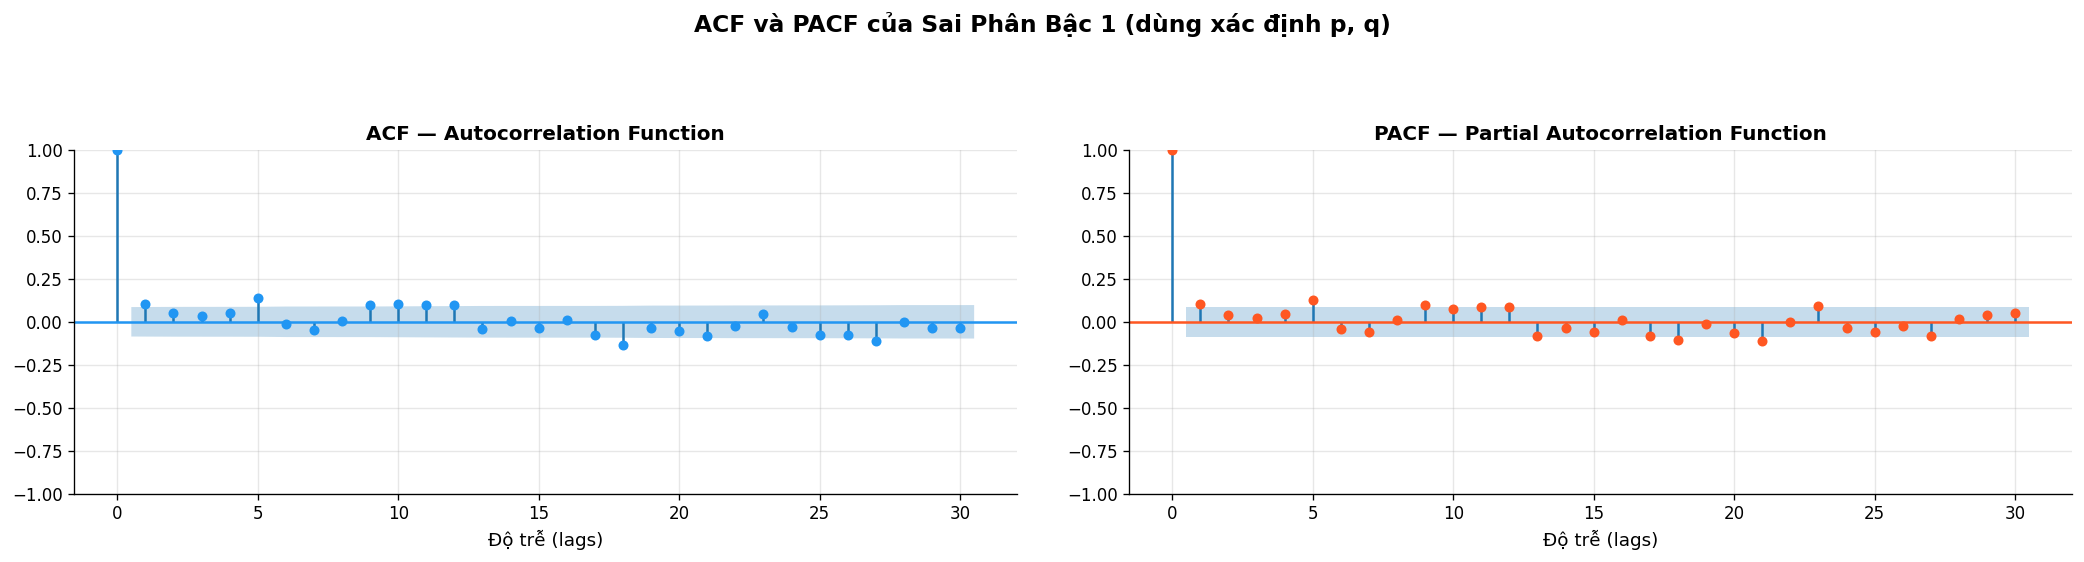

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('ACF và PACF của Sai Phân Bậc 1 (dùng xác định p, q)', fontsize=14, fontweight='bold')
plot_acf(df_d1,  ax=axes[0], lags=30, alpha=0.05, color='#2196F3', title='')
plot_pacf(df_d1, ax=axes[1], lags=30, alpha=0.05, color='#FF5722', title='')
axes[0].set_title('ACF — Autocorrelation Function', fontweight='bold', fontsize=12)
axes[1].set_title('PACF — Partial Autocorrelation Function', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Độ trễ (lags)')
axes[1].set_xlabel('Độ trễ (lags)')
plt.tight_layout(pad=3.0)
plt.savefig('03_acf_pacf.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Grid Search AIC/BIC — Chọn Bậc (p, d, q)

Grid search p∈[0,4], q∈[0,4], d=1 trên tập TRAIN...


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

  p=0 hoàn tất


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

  p=1 hoàn tất


...

  p=2 hoàn tất


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

  p=3 hoàn tất


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

  p=4 hoàn tất

✓ Tốt nhất theo AIC: ARIMA(2,1,4)  AIC=9519.75


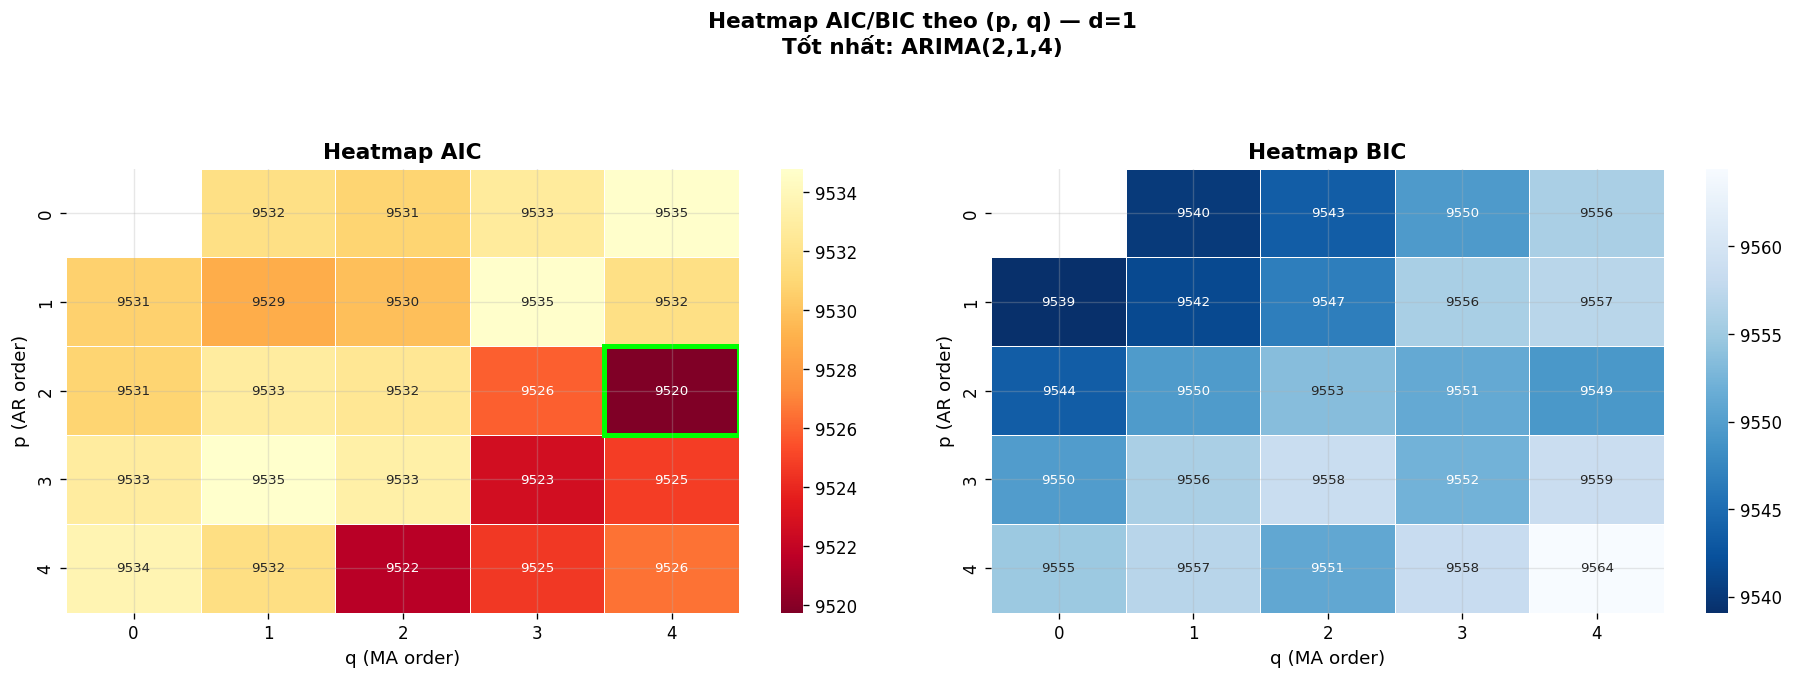

In [7]:
print(f'Grid search p∈[0,{P_MAX}], q∈[0,{Q_MAX}], d={d_order} trên tập TRAIN...')
aic_grid = np.full((P_MAX+1, Q_MAX+1), np.nan)
bic_grid = np.full((P_MAX+1, Q_MAX+1), np.nan)
best_aic, best_order = np.inf, (1, d_order, 1)

for p in range(P_MAX+1):
    for q in range(Q_MAX+1):
        if p == 0 and q == 0: continue
        try:
            m = ARIMA(train, order=(p, d_order, q)).fit()
            aic_grid[p,q] = m.aic
            bic_grid[p,q] = m.bic
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, d_order, q)
        except:
            pass
    print(f'  p={p} hoàn tất')

p_opt, d_opt, q_opt = best_order
print(f'\n✓ Tốt nhất theo AIC: ARIMA({p_opt},{d_opt},{q_opt})  AIC={best_aic:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Heatmap AIC/BIC theo (p, q) — d={d_order}\nTốt nhất: ARIMA({p_opt},{d_opt},{q_opt})',
             fontsize=13, fontweight='bold')

for ax, grid, label, cmap in zip(axes, [aic_grid, bic_grid], ['AIC','BIC'], ['YlOrRd_r','Blues_r']):
    mask = np.isnan(grid)
    sns.heatmap(grid, mask=mask, annot=True, fmt='.0f', cmap=cmap, ax=ax,
                xticklabels=range(Q_MAX+1), yticklabels=range(P_MAX+1),
                linewidths=0.5, annot_kws={'size': 8})
    ax.set_xlabel('q (MA order)', fontsize=11)
    ax.set_ylabel('p (AR order)', fontsize=11)
    ax.set_title(f'Heatmap {label}', fontweight='bold')
    if label == 'AIC':
        ax.add_patch(plt.Rectangle((q_opt, p_opt), 1, 1, fill=False, edgecolor='lime', lw=3, label=f'Best ({p_opt},{d_opt},{q_opt})'))

plt.tight_layout(pad=3.0)
plt.savefig('04_aic_bic_grid.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Cấp Độ 1 — Mô Hình AR / MA / ARIMA (Rolling Backtest 10 Ngày)

In [8]:
orders = {
    'AR':    (p_opt, 0,     0),
    'MA':    (0,     d_opt, q_opt),
    'ARIMA': (p_opt, d_opt, q_opt),
}

preds   = {}
metrics = {}
all_metrics = {}

for name, order in orders.items():
    print(f'Rolling forecast [{name}({order[0]},{order[1]},{order[2]})] — {TEST_DAYS} bước...', end=' ')
    fc = []
    for i in range(TEST_DAYS):
        window = df.iloc[:-(TEST_DAYS - i)] if i < TEST_DAYS else df
        try:
            m = ARIMA(window, order=order).fit()
            fc.append(float(m.forecast(1).iloc[0]))
        except:
            fc.append(window.iloc[-1])
    preds[name] = pd.Series(fc, index=test.index)
    m_val = metrics_fn(test.values, preds[name].values)
    metrics[name] = m_val
    all_metrics[name] = m_val
    print(f'MAPE={m_val["MAPE"]:.2f}%')

# In bảng so sánh cho từng model
for name in orders:
    print_comparison_table(test, preds[name], name)

Rolling forecast [AR(2,0,0)] — 10 bước... 

d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

MAPE=1.76%
Rolling forecast [MA(0,1,4)] — 10 bước... 

d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

MAPE=1.80%
Rolling forecast [ARIMA(2,1,4)] — 10 bước... 

d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

MAPE=1.81%

  [AR] BẢNG SO SÁNH GIÁ THỰC TẾ vs DỰ ĐOÁN
  Ngày          Thực tế (VND)  Dự đoán (VND)   Chênh lệch  Sai số %
  ------------ -------------- -------------- ------------ ---------
  2026-06-04          200,200        196,526       -3,674    -1.84%
  2026-06-05          207,000        200,434       -6,566    -3.17%
  2026-06-08          195,000        207,796      +12,796    +6.56%
  2026-06-09          193,200        193,507         +307    +0.16%
  2026-06-10          196,000        192,887       -3,113    -1.59%
  2026-06-11          196,000        196,215         +215    +0.11%
  2026-06-12          195,500        195,877         +377    +0.19%
  2026-06-15          192,600        195,339       +2,739    +1.42%
  2026-06-16          194,000        192,161       -1,839    -0.95%
  2026-06-17          190,900        194,058       +3,158    +1.65%
───────────────────────────────────────────────────────────────────────────
  MAE=3,479 VND  |  RMSE=5,012 VND  |  MAPE=1.76%


 

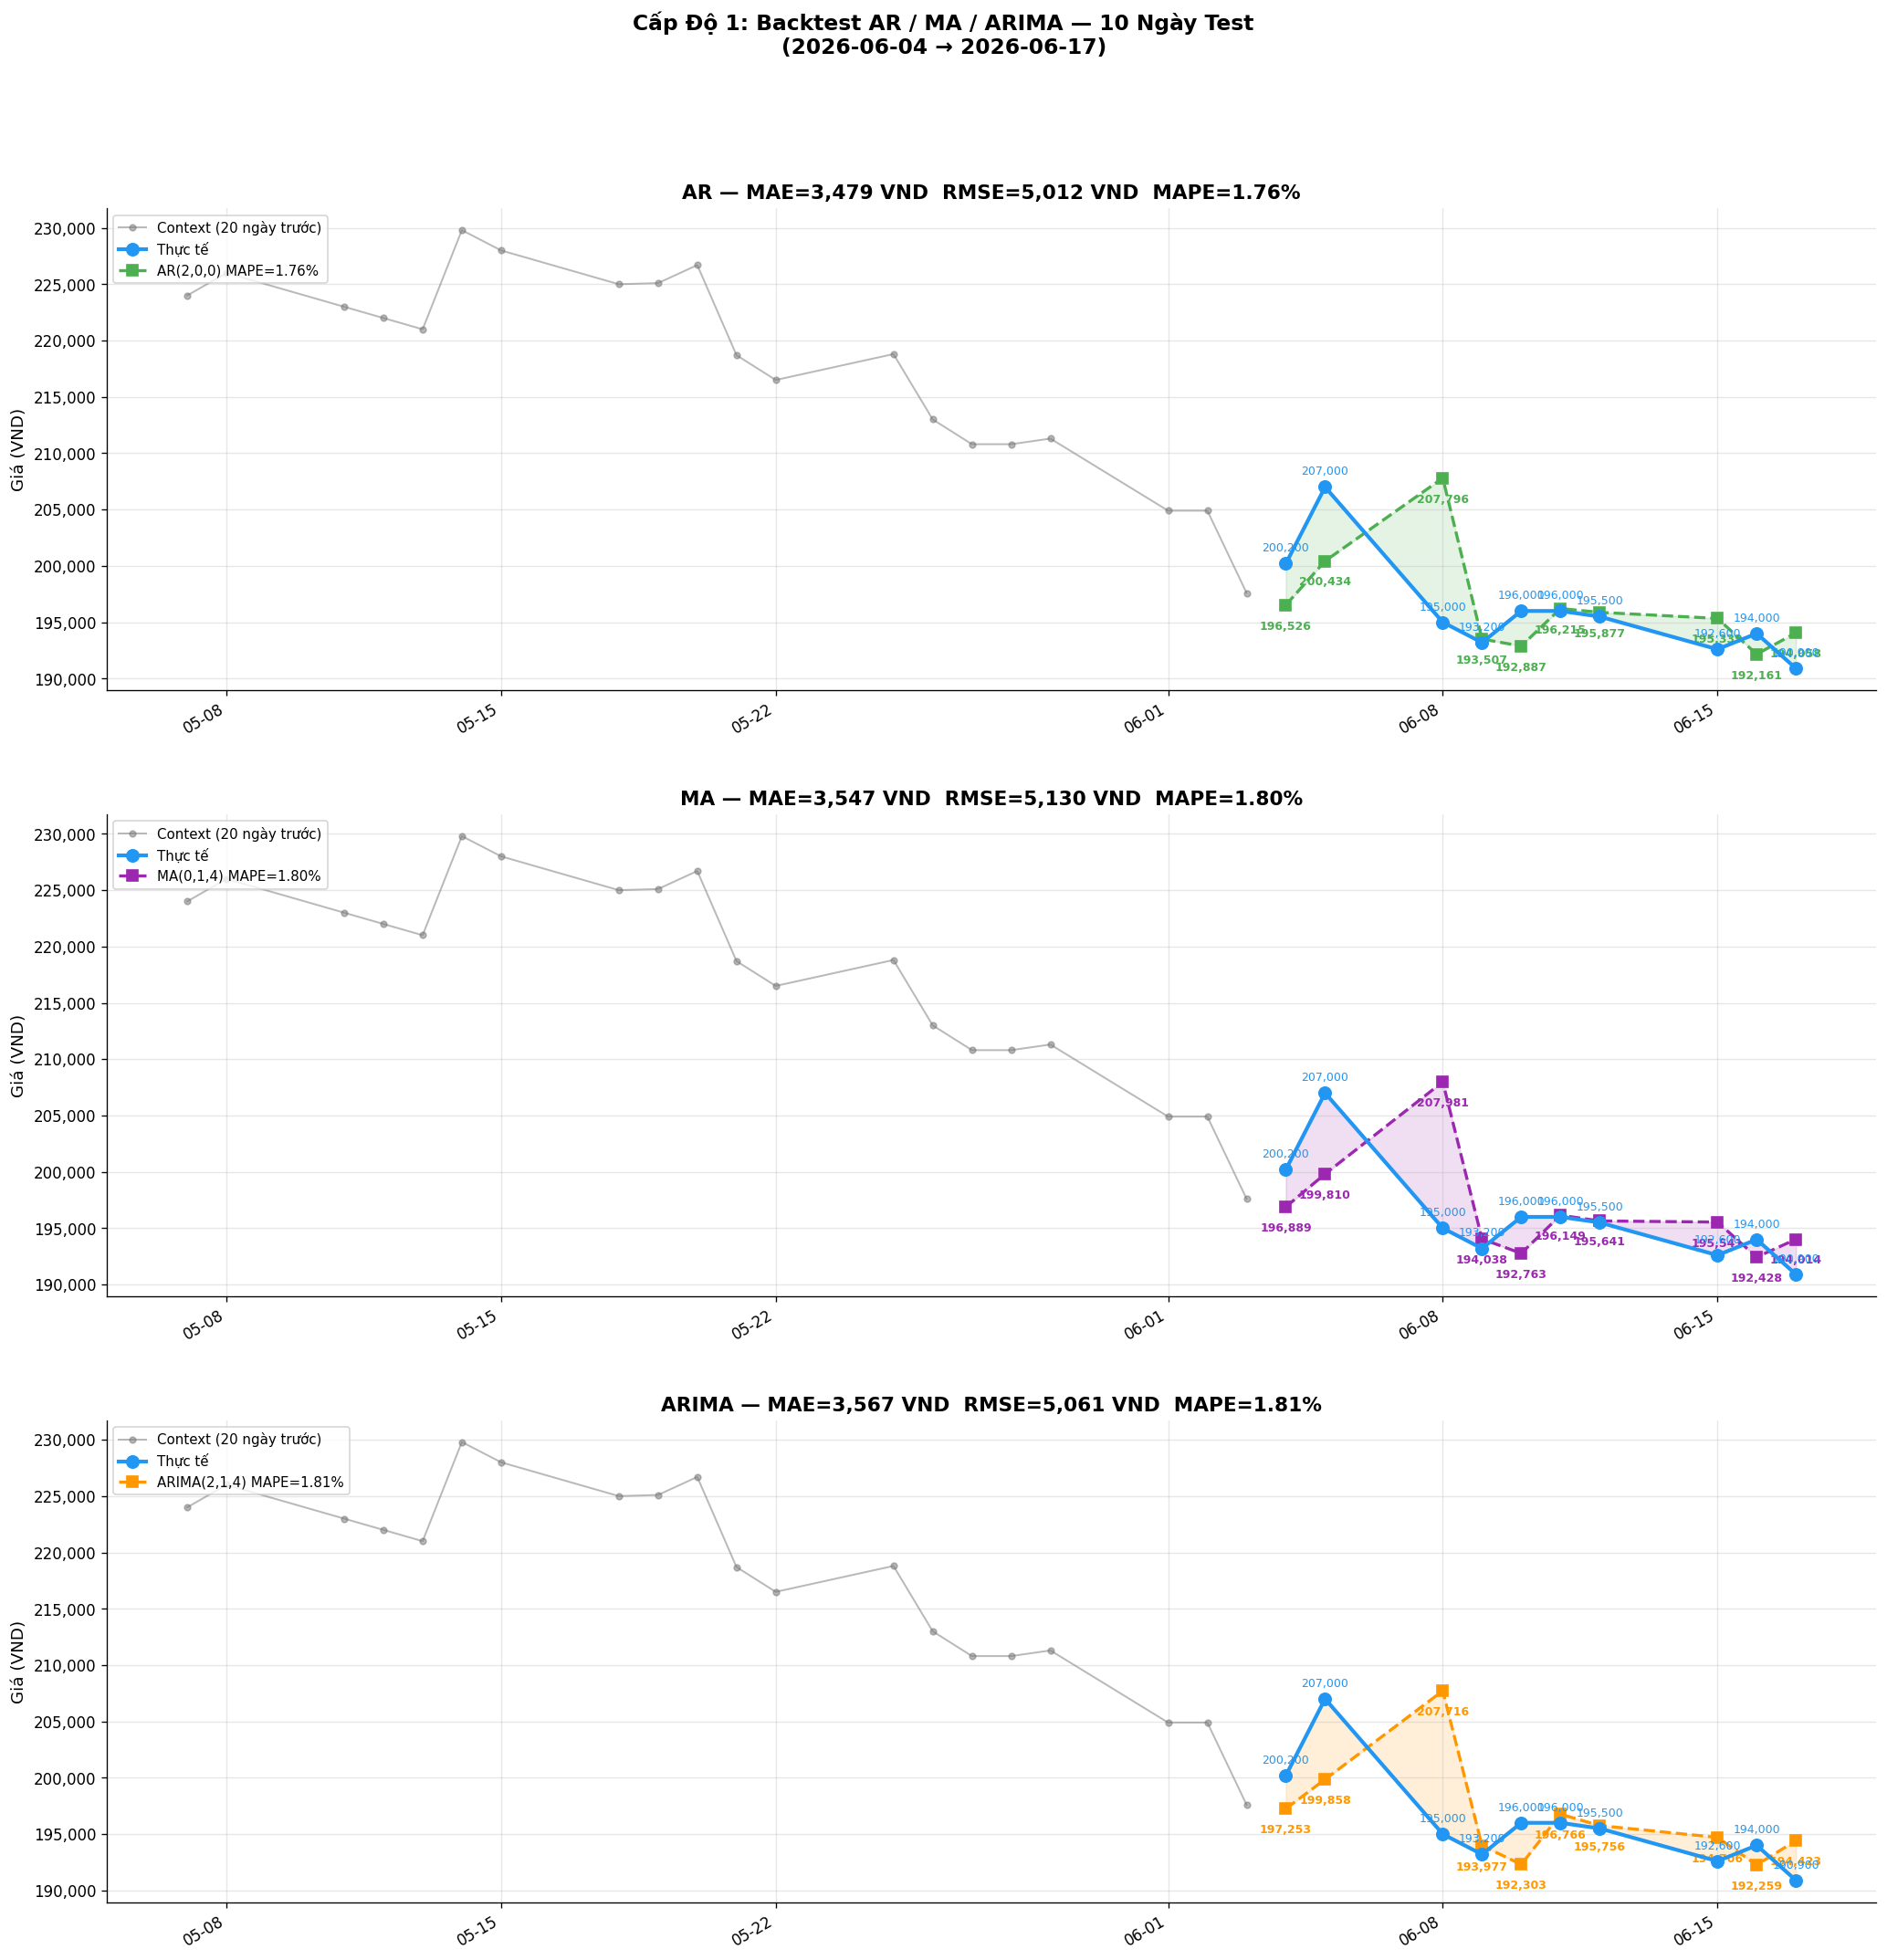

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(18, 18))
fig.suptitle(f'Cấp Độ 1: Backtest AR / MA / ARIMA — 10 Ngày Test\n({test.index[0].date()} → {test.index[-1].date()})',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (name, pred) in zip(axes, preds.items()):
    # Context 20 ngày trước test
    ctx = df.iloc[-(TEST_DAYS + 20):-TEST_DAYS]
    ax.plot(ctx.index,  ctx.values,  'o-', color='#757575', lw=1.2, ms=4, alpha=0.5, label='Context (20 ngày trước)')
    ax.plot(test.index, test.values, 'o-', color='#2196F3', lw=2.5, ms=8, label='Thực tế', zorder=5)
    ax.plot(test.index, pred.values, 's--', color=COLORS[list(orders.keys()).index(name)+2], lw=2.0, ms=7,
            label=f'{name}({orders[name][0]},{orders[name][1]},{orders[name][2]}) MAPE={metrics[name]["MAPE"]:.2f}%')
    ax.fill_between(test.index, test.values, pred.values, alpha=0.15,
                    color=COLORS[list(orders.keys()).index(name)+2])
    # Annotate predicted values
    for d, v in zip(test.index, pred.values):
        ax.annotate(f'{v:,.0f}', (d, v), textcoords='offset points', xytext=(0, -16), ha='center', fontsize=7.5,
                    color=COLORS[list(orders.keys()).index(name)+2], fontweight='bold')
    for d, v in zip(test.index, test.values):
        ax.annotate(f'{v:,.0f}', (d, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=7.5,
                    color='#2196F3')
    ax.set_title(f'{name} — MAE={fmt_vnd(metrics[name]["MAE"])} VND  RMSE={fmt_vnd(metrics[name]["RMSE"])} VND  MAPE={metrics[name]["MAPE"]:.2f}%',
                 fontweight='bold')
    ax.set_ylabel('Giá (VND)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=9, loc='upper left')

plt.tight_layout(pad=3.5)
plt.savefig('05_backtest_ar_ma_arima.png', dpi=120, bbox_inches='tight')
plt.show()

Đang fit ARIMA(2,1,4) trên toàn bộ dữ liệu để dự đoán tương lai...


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)



───────────────────────────────────────────────────────
  DỰ ĐOÁN 10 NGÀY TƯƠNG LAI — ARIMA(2,1,4)
───────────────────────────────────────────────────────
  Ngày          Dự đoán (VND)      Lower 95%      Upper 95%
  ------------ -------------- -------------- --------------
  2026-06-18          191,165        184,682        197,647
  2026-06-19          190,925        181,410        200,440
  2026-06-22          190,522        178,470        202,575
  2026-06-23          189,932        175,636        204,229
  2026-06-24          189,714        173,151        206,277
  2026-06-25          190,007        171,273        208,741
  2026-06-26          190,469        169,874        211,064
  2026-06-29          190,659        168,552        212,766
  2026-06-30          190,447        167,034        213,860
  2026-07-01          190,086        165,394        214,779
───────────────────────────────────────────────────────


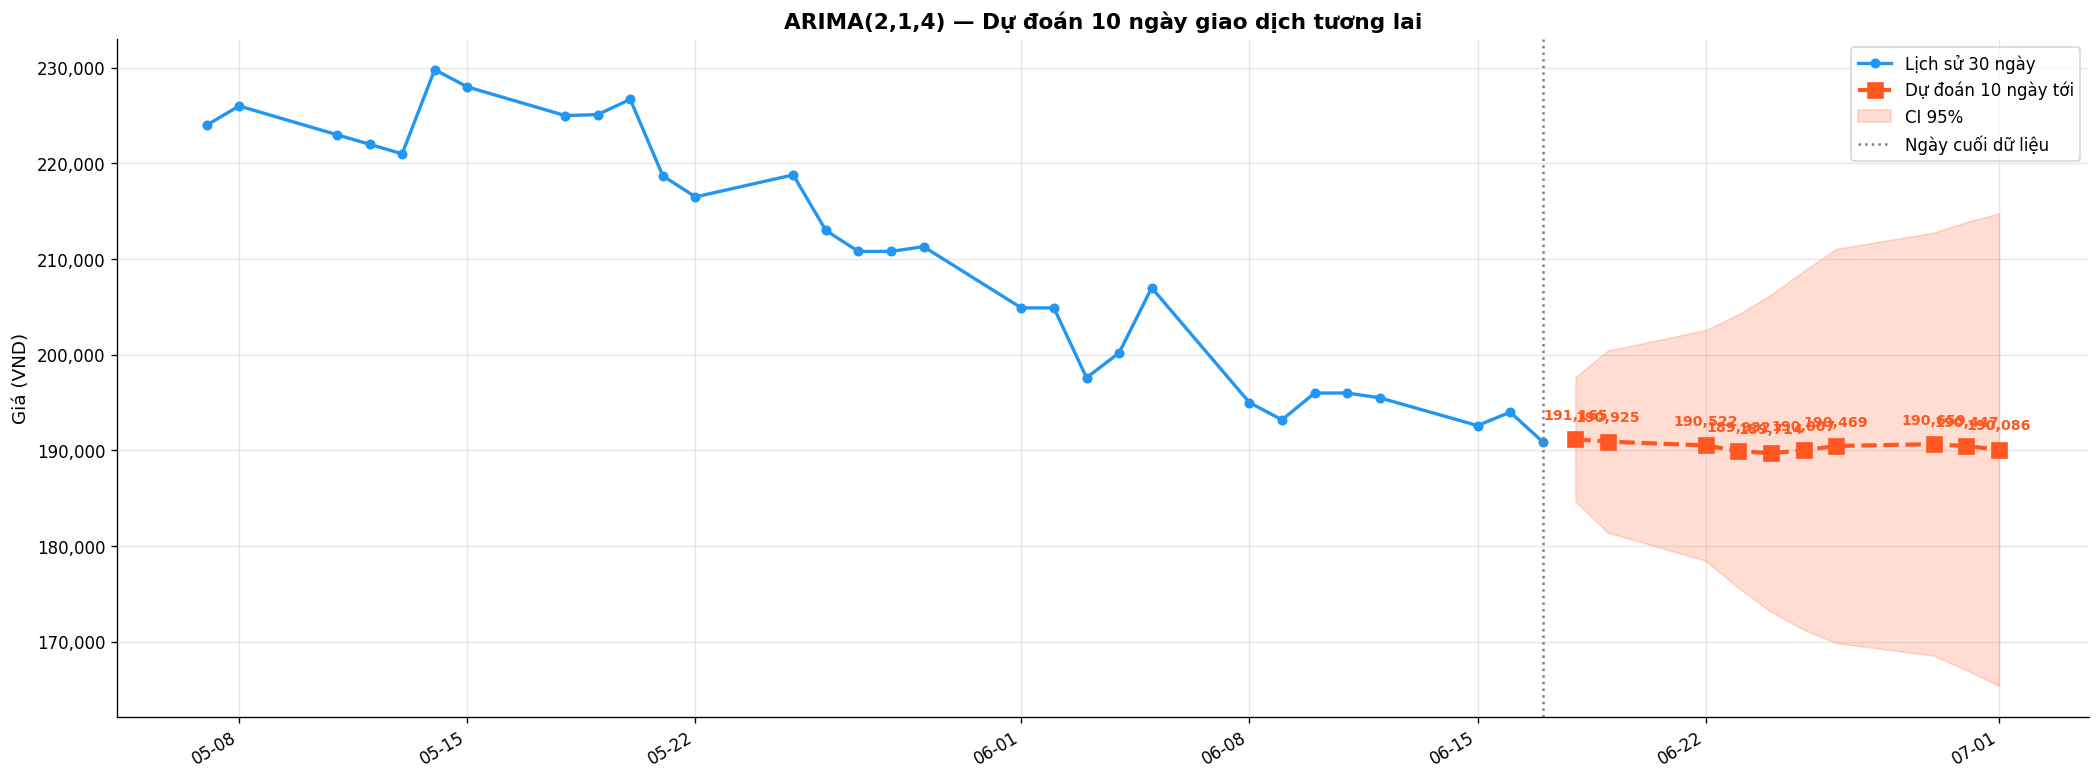

In [10]:
# ── Dự đoán 10 ngày TỪ NGÀY HÔM NAY (tương lai) ──────────────────────
print(f'Đang fit ARIMA({p_opt},{d_opt},{q_opt}) trên toàn bộ dữ liệu để dự đoán tương lai...')
model_full = ARIMA(df, order=(p_opt, d_opt, q_opt)).fit()
fc_result  = model_full.get_forecast(steps=FORECAST)
fc_mean    = fc_result.predicted_mean
fc_ci      = fc_result.conf_int(alpha=0.05)

last_date  = df.index[-1]
bdays      = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST)
fc_mean.index = bdays
fc_ci.index   = bdays

print(f'\n{"─"*55}')
print(f'  DỰ ĐOÁN {FORECAST} NGÀY TƯƠNG LAI — ARIMA({p_opt},{d_opt},{q_opt})')
print(f'{"─"*55}')
print(f'  {"Ngày":<12} {"Dự đoán (VND)":>14} {"Lower 95%":>14} {"Upper 95%":>14}')
print(f'  {"-"*12} {"-"*14} {"-"*14} {"-"*14}')
for d, v, lo, hi in zip(bdays, fc_mean, fc_ci.iloc[:,0], fc_ci.iloc[:,1]):
    print(f'  {str(d.date()):<12} {fmt_vnd(v):>14} {fmt_vnd(lo):>14} {fmt_vnd(hi):>14}')
print(f'{"─"*55}')

fig, ax = plt.subplots(figsize=(18, 7))
ctx30 = df.iloc[-30:]
ax.plot(ctx30.index, ctx30.values, 'o-', color='#2196F3', lw=2, ms=5, label='Lịch sử 30 ngày')
ax.plot(bdays, fc_mean.values, 's--', color='#FF5722', lw=2.5, ms=9, label=f'Dự đoán {FORECAST} ngày tới')
ax.fill_between(bdays, fc_ci.iloc[:,0], fc_ci.iloc[:,1], alpha=0.2, color='#FF5722', label='CI 95%')
for d, v in zip(bdays, fc_mean.values):
    ax.annotate(f'{v:,.0f}', (d, v), textcoords='offset points', xytext=(0, 12), ha='center', fontsize=8.5,
                color='#FF5722', fontweight='bold')
ax.axvline(df.index[-1], color='gray', ls=':', lw=1.5, label='Ngày cuối dữ liệu')
ax.set_title(f'ARIMA({p_opt},{d_opt},{q_opt}) — Dự đoán {FORECAST} ngày giao dịch tương lai', fontsize=13, fontweight='bold')
ax.set_ylabel('Giá (VND)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=10)
plt.tight_layout(pad=2.5)
plt.savefig('06_forecast_future.png', dpi=120, bbox_inches='tight')
plt.show()

d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


Ljung-Box test:
      lb_stat  lb_pvalue
10   8.498956   0.580220
20  22.618024   0.307937
→ p > 0.05: phần dư là nhiễu trắng (mô hình tốt)


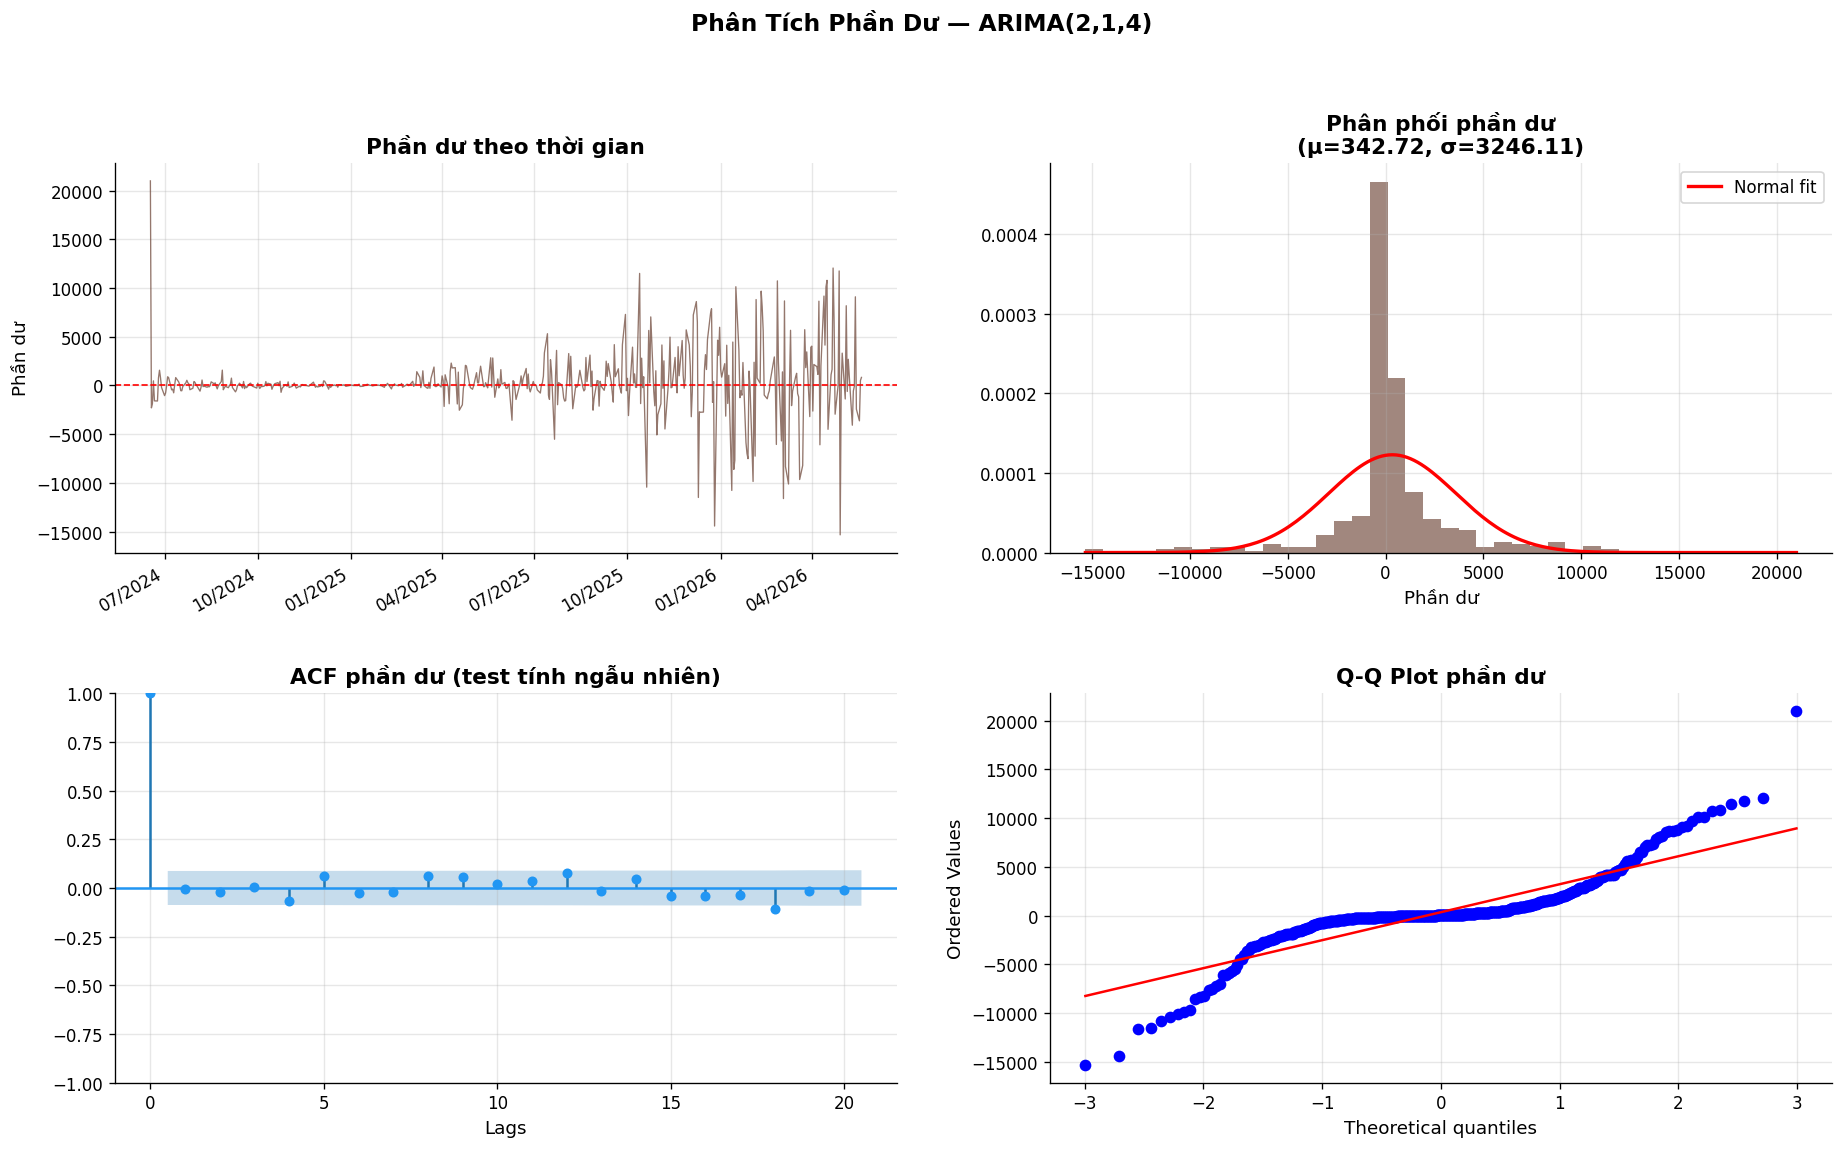

In [11]:
# ── Phân tích phần dư ──────────────────────────────────────────────────
model_train = ARIMA(train, order=(p_opt, d_opt, q_opt)).fit()
resid = model_train.resid

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'Phân Tích Phần Dư — ARIMA({p_opt},{d_opt},{q_opt})', fontsize=14, fontweight='bold')

axes[0,0].plot(resid.index, resid, color='#795548', lw=0.8, alpha=0.8)
axes[0,0].axhline(0, color='r', ls='--', lw=1)
axes[0,0].set_title('Phần dư theo thời gian', fontweight='bold')
axes[0,0].set_ylabel('Phần dư')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=30, ha='right')

axes[0,1].hist(resid, bins=40, color='#795548', alpha=0.7, density=True)
xr = np.linspace(resid.min(), resid.max(), 200)
axes[0,1].plot(xr, stats.norm.pdf(xr, resid.mean(), resid.std()), 'r-', lw=2, label='Normal fit')
axes[0,1].set_title(f'Phân phối phần dư\n(μ={resid.mean():.2f}, σ={resid.std():.2f})', fontweight='bold')
axes[0,1].set_xlabel('Phần dư')
axes[0,1].legend()

plot_acf(resid, ax=axes[1,0], lags=20, color='#2196F3', title='')
axes[1,0].set_title('ACF phần dư (test tính ngẫu nhiên)', fontweight='bold')
axes[1,0].set_xlabel('Lags')

stats.probplot(resid, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot phần dư', fontweight='bold')

lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
print(f'Ljung-Box test:\n{lb.to_string()}')
print('→ p > 0.05: phần dư là nhiễu trắng (mô hình tốt)' if (lb['lb_pvalue'] > 0.05).all() else '→ Còn tương quan trong phần dư')

plt.tight_layout(pad=3.0)
plt.savefig('07_residuals.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Cấp Độ 2 — Optuna ARIMA (Tối Ưu Hóa Tham Số trên Val Set)

In [12]:
# Optuna: tối ưu trên VAL set, test trên TEST set
def objective(trial):
    p = trial.suggest_int('p', 0, P_MAX)
    d = trial.suggest_int('d', 0, 2)
    q = trial.suggest_int('q', 0, Q_MAX)
    if p == 0 and q == 0: return 1e9
    try:
        m = ARIMA(train, order=(p,d,q)).fit()
        fc_val = []
        for i in range(VAL_DAYS):
            w = df.iloc[:-(TEST_DAYS + VAL_DAYS - i)]
            fc_val.append(float(ARIMA(w, order=(p,d,q)).fit().forecast(1).iloc[0]))
        return np.sqrt(mean_squared_error(val.values, fc_val))
    except:
        return 1e9

print('Optuna tối ưu hóa (80 trials)...')
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=80, show_progress_bar=False)

best_p2 = study.best_params['p']
best_d2 = study.best_params['d']
best_q2 = study.best_params['q']
print(f'✓ Optuna tốt nhất: ARIMA({best_p2},{best_d2},{best_q2})  Val-RMSE={study.best_value:.2f}')

# Rolling backtest Optuna trên TEST
print(f'Rolling backtest Optuna trên {TEST_DAYS} ngày test...')
fc_opt = []
for i in range(TEST_DAYS):
    w = df.iloc[:-(TEST_DAYS - i)]
    try:
        fc_opt.append(float(ARIMA(w, order=(best_p2,best_d2,best_q2)).fit().forecast(1).iloc[0]))
    except:
        fc_opt.append(w.iloc[-1])

pred_optuna = pd.Series(fc_opt, index=test.index)
m_optuna = metrics_fn(test.values, pred_optuna.values)
all_metrics[f'ARIMA-Optuna({best_p2},{best_d2},{best_q2})'] = m_optuna
print_comparison_table(test, pred_optuna, f'ARIMA-Optuna({best_p2},{best_d2},{best_q2})')

Optuna tối ưu hóa (80 trials)...


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

✓ Optuna tốt nhất: ARIMA(3,2,0)  Val-RMSE=4253.80
Rolling backtest Optuna trên 10 ngày test...


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\


  [ARIMA-Optuna(3,2,0)] BẢNG SO SÁNH GIÁ THỰC TẾ vs DỰ ĐOÁN
  Ngày          Thực tế (VND)  Dự đoán (VND)   Chênh lệch  Sai số %
  ------------ -------------- -------------- ------------ ---------
  2026-06-04          200,200        194,057       -6,143    -3.07%
  2026-06-05          207,000        197,773       -9,227    -4.46%
  2026-06-08          195,000        208,556      +13,556    +6.95%
  2026-06-09          193,200        191,260       -1,940    -1.00%
  2026-06-10          196,000        192,032       -3,968    -2.02%
  2026-06-11          196,000        195,638         -362    -0.18%
  2026-06-12          195,500        193,226       -2,274    -1.16%
  2026-06-15          192,600        195,497       +2,897    +1.50%
  2026-06-16          194,000        192,234       -1,766    -0.91%
  2026-06-17          190,900        193,728       +2,828    +1.48%
───────────────────────────────────────────────────────────────────────────
  MAE=4,496 VND  |  RMSE=5,924 VND  |  MAPE=2.2

d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


{'MAE': 4496.040756532782,
 'RMSE': 5924.203672142829,
 'MAPE': 2.2749771049035608}

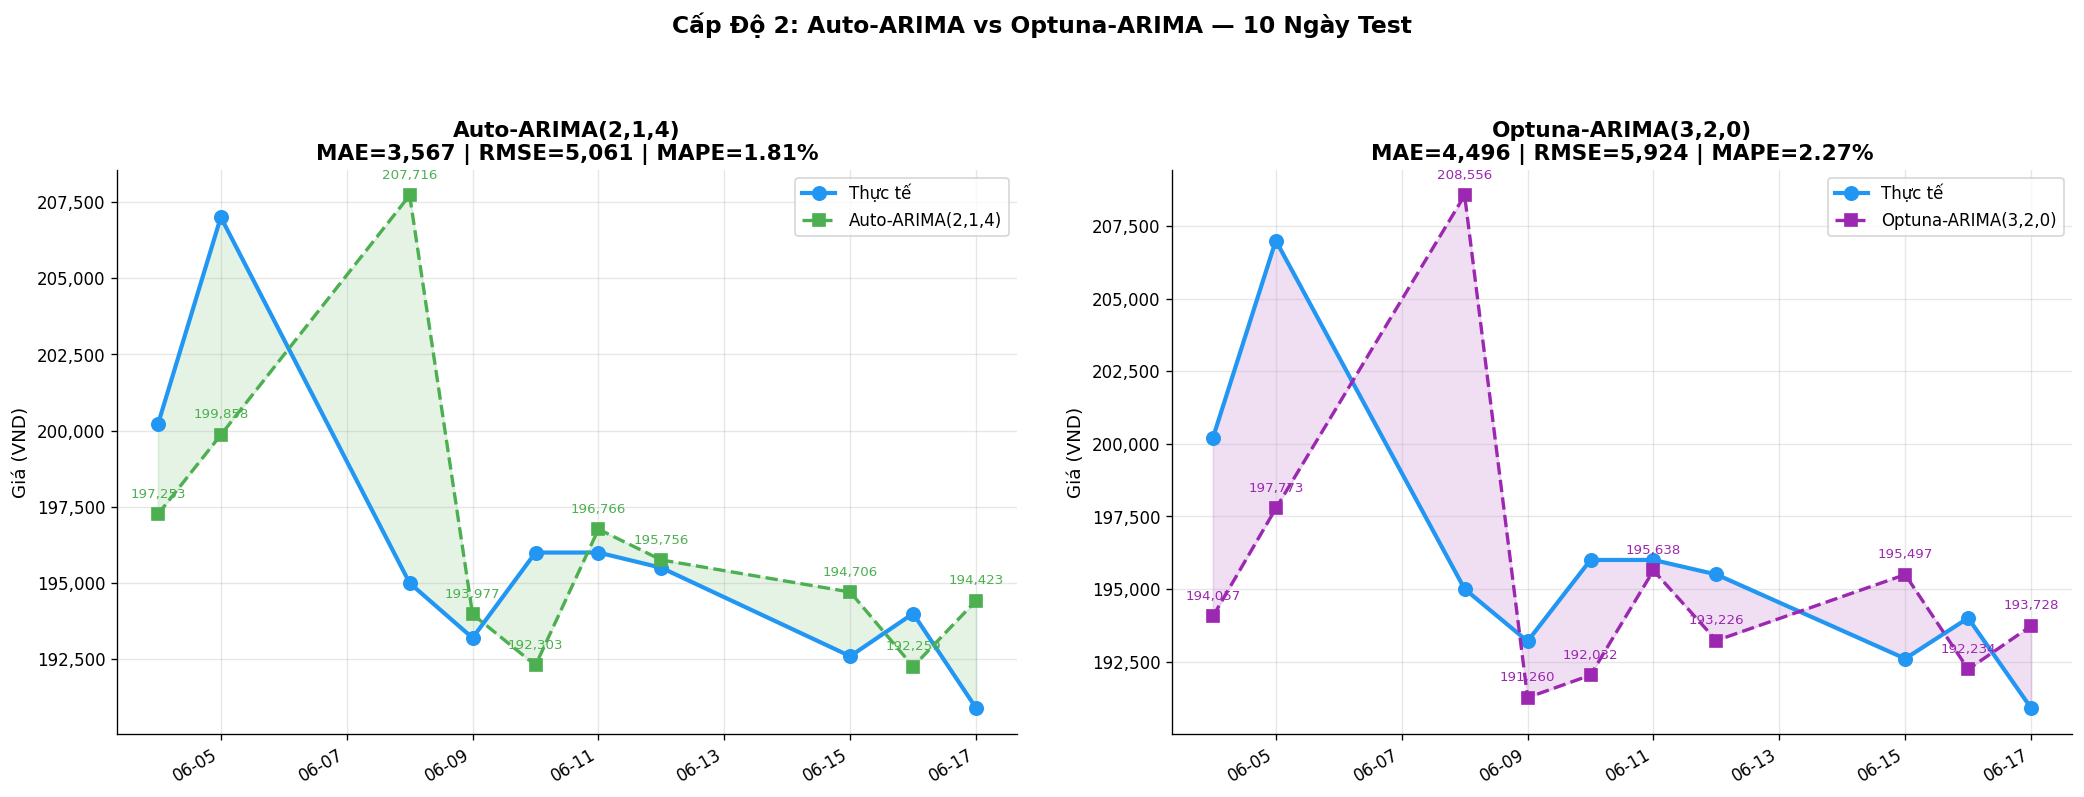

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Cấp Độ 2: Auto-ARIMA vs Optuna-ARIMA — 10 Ngày Test', fontsize=14, fontweight='bold')

for ax, (name2, pred2, col) in zip(axes, [
    (f'Auto-ARIMA({p_opt},{d_opt},{q_opt})', preds['ARIMA'], '#4CAF50'),
    (f'Optuna-ARIMA({best_p2},{best_d2},{best_q2})', pred_optuna, '#9C27B0')
]):
    ax.plot(test.index, test.values,  'o-', color='#2196F3', lw=2.5, ms=8, label='Thực tế')
    ax.plot(test.index, pred2.values, 's--', color=col, lw=2.0, ms=7, label=name2)
    ax.fill_between(test.index, test.values, pred2.values, alpha=0.15, color=col)
    m2 = metrics_fn(test.values, pred2.values)
    ax.set_title(f'{name2}\nMAE={fmt_vnd(m2["MAE"])} | RMSE={fmt_vnd(m2["RMSE"])} | MAPE={m2["MAPE"]:.2f}%', fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=10)
    ax.set_ylabel('Giá (VND)')
    for d, v in zip(test.index, pred2.values):
        ax.annotate(f'{v:,.0f}', (d, v), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8, color=col)

plt.tight_layout(pad=3.0)
plt.savefig('08_optuna_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Cấp Độ 3 — Prophet

14:26:31 - cmdstanpy - INFO - Chain [1] start processing


Fitting Prophet và rolling backtest 10 ngày...


14:26:31 - cmdstanpy - INFO - Chain [1] done processing
14:26:31 - cmdstanpy - INFO - Chain [1] start processing


  Bước 1/10


14:26:31 - cmdstanpy - INFO - Chain [1] done processing
14:26:32 - cmdstanpy - INFO - Chain [1] start processing
14:26:32 - cmdstanpy - INFO - Chain [1] done processing
14:26:32 - cmdstanpy - INFO - Chain [1] start processing


...

14:26:34 - cmdstanpy - INFO - Chain [1] done processing
14:26:35 - cmdstanpy - INFO - Chain [1] start processing
14:26:35 - cmdstanpy - INFO - Chain [1] done processing
14:26:35 - cmdstanpy - INFO - Chain [1] start processing


  Bước 9/10


14:26:35 - cmdstanpy - INFO - Chain [1] done processing
14:26:36 - cmdstanpy - INFO - Chain [1] start processing



  [Prophet] BẢNG SO SÁNH GIÁ THỰC TẾ vs DỰ ĐOÁN
  Ngày          Thực tế (VND)  Dự đoán (VND)   Chênh lệch  Sai số %
  ------------ -------------- -------------- ------------ ---------
  2026-06-04          200,200        202,742       +2,542    +1.27%
  2026-06-05          207,000        199,725       -7,275    -3.51%
  2026-06-08          195,000        192,660       -2,340    -1.20%
  2026-06-09          193,200        192,422         -778    -0.40%
  2026-06-10          196,000        189,791       -6,209    -3.17%
  2026-06-11          196,000        190,698       -5,302    -2.71%
  2026-06-12          195,500        189,600       -5,900    -3.02%
  2026-06-15          192,600        182,954       -9,646    -5.01%
  2026-06-16          194,000        185,149       -8,851    -4.56%
  2026-06-17          190,900        186,139       -4,761    -2.49%
───────────────────────────────────────────────────────────────────────────
  MAE=5,360 VND  |  RMSE=6,008 VND  |  MAPE=2.73%



14:26:36 - cmdstanpy - INFO - Chain [1] done processing


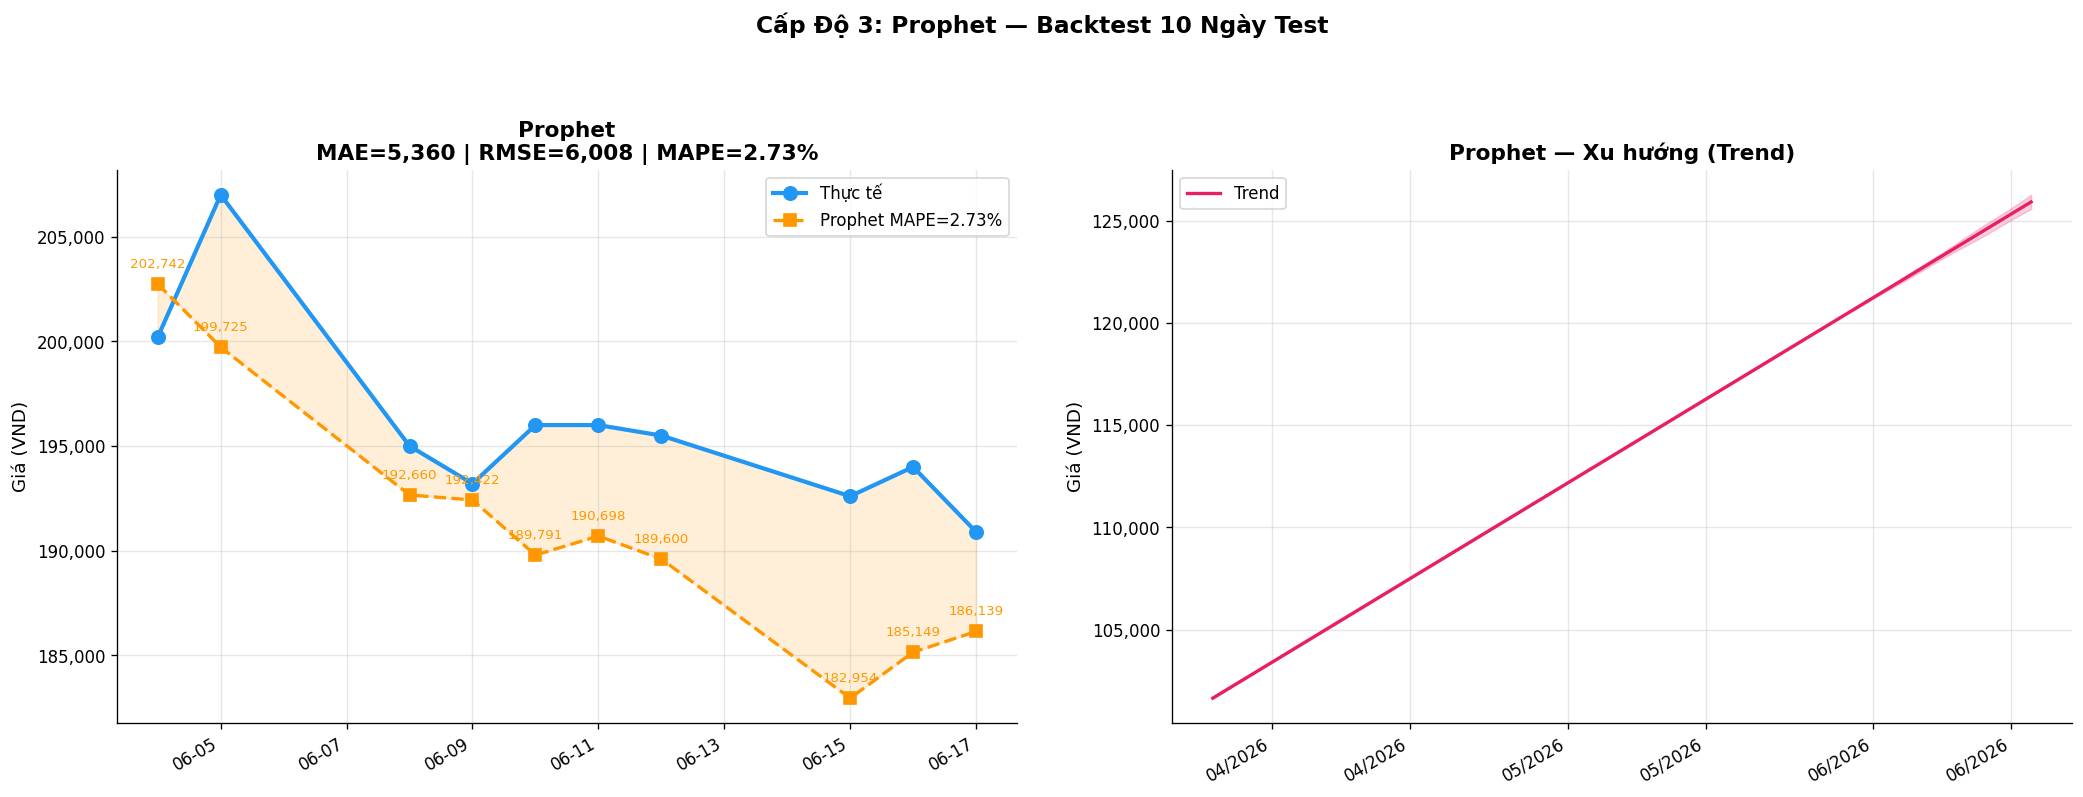

In [14]:
# Prophet: train trên train set, backtest trên test (10 ngày)
def make_prophet_df(series):
    return pd.DataFrame({'ds': series.index, 'y': series.values})

print('Fitting Prophet và rolling backtest 10 ngày...')
fc_prophet = []
for i in range(TEST_DAYS):
    w = df.iloc[:-(TEST_DAYS - i)]
    m_p = Prophet(changepoint_prior_scale=0.05, seasonality_mode='multiplicative',
                  daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
    m_p.fit(make_prophet_df(w))
    fut = m_p.make_future_dataframe(periods=1, freq='B')
    fc_prophet.append(float(m_p.predict(fut)['yhat'].iloc[-1]))
    if i % 2 == 0: print(f'  Bước {i+1}/{TEST_DAYS}')

pred_prophet = pd.Series(fc_prophet, index=test.index)
m_prophet = metrics_fn(test.values, pred_prophet.values)
all_metrics['Prophet'] = m_prophet
print_comparison_table(test, pred_prophet, 'Prophet')

# Fit final Prophet cho decomposition
m_p_final = Prophet(changepoint_prior_scale=0.05, seasonality_mode='multiplicative',
                    daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
m_p_final.fit(make_prophet_df(train))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Cấp Độ 3: Prophet — Backtest 10 Ngày Test', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(test.index, test.values,        'o-', color='#2196F3', lw=2.5, ms=8, label='Thực tế')
ax.plot(test.index, pred_prophet.values,'s--', color='#FF9800', lw=2.0, ms=7,
        label=f'Prophet MAPE={m_prophet["MAPE"]:.2f}%')
ax.fill_between(test.index, test.values, pred_prophet.values, alpha=0.15, color='#FF9800')
ax.set_title(f'Prophet\nMAE={fmt_vnd(m_prophet["MAE"])} | RMSE={fmt_vnd(m_prophet["RMSE"])} | MAPE={m_prophet["MAPE"]:.2f}%', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=10)
ax.set_ylabel('Giá (VND)')
for d, v in zip(test.index, pred_prophet.values):
    ax.annotate(f'{v:,.0f}', (d, v), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8, color='#FF9800')

ax2 = axes[1]
fut_d = m_p_final.make_future_dataframe(periods=20, freq='B')
fcst_d = m_p_final.predict(fut_d)
ax2.plot(fcst_d['ds'].tail(60), fcst_d['trend'].tail(60), color='#E91E63', lw=2, label='Trend')
ax2.fill_between(fcst_d['ds'].tail(60), fcst_d['trend_lower'].tail(60), fcst_d['trend_upper'].tail(60),
                 alpha=0.2, color='#E91E63')
ax2.set_title('Prophet — Xu hướng (Trend)', fontweight='bold')
ax2.set_ylabel('Giá (VND)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.legend()

plt.tight_layout(pad=3.0)
plt.savefig('09_prophet.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Cấp Độ 4 — Ensemble (ARIMA + Prophet)

Tối ưu trọng số Ensemble trên VAL set...


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
14:26:38 - cmdstanpy - INFO - Chain [1] start processing
14:26:38 - cmdstanpy - INFO - Chain [1] done processing
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.

  Val bước 1/10


14:26:39 - cmdstanpy - INFO - Chain [1] start processing
14:26:39 - cmdstanpy - INFO - Chain [1] done processing
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
14:26:40 - cmdstanpy - INFO - Chain [1] start processing
14:26:41 - cmdstanpy - INFO - Chain [1] done processing
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\

  Val bước 4/10


14:26:43 - cmdstanpy - INFO - Chain [1] start processing
14:26:43 - cmdstanpy - INFO - Chain [1] done processing
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
14:26:44 - cmdstanpy - INFO - Chain [1] start processing
14:26:44 - cmdstanpy - INFO - Chain [1] done processing
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\

  Val bước 7/10


14:26:47 - cmdstanpy - INFO - Chain [1] start processing
14:26:47 - cmdstanpy - INFO - Chain [1] done processing
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
14:26:48 - cmdstanpy - INFO - Chain [1] start processing
14:26:48 - cmdstanpy - INFO - Chain [1] done processing
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\

  Val bước 10/10
✓ Trọng số tốt nhất: w_ARIMA=1.00, w_Prophet=0.00  Val-MAPE=1.72%

  [Ensemble ARIMA×1.00 + Prophet×0.00] BẢNG SO SÁNH GIÁ THỰC TẾ vs DỰ ĐOÁN
  Ngày          Thực tế (VND)  Dự đoán (VND)   Chênh lệch  Sai số %
  ------------ -------------- -------------- ------------ ---------
  2026-06-04          200,200        197,253       -2,947    -1.47%
  2026-06-05          207,000        199,858       -7,142    -3.45%
  2026-06-08          195,000        207,716      +12,716    +6.52%
  2026-06-09          193,200        193,977         +777    +0.40%
  2026-06-10          196,000        192,303       -3,697    -1.89%
  2026-06-11          196,000        196,766         +766    +0.39%
  2026-06-12          195,500        195,756         +256    +0.13%
  2026-06-15          192,600        194,706       +2,106    +1.09%
  2026-06-16          194,000        192,259       -1,741    -0.90%
  2026-06-17          190,900        194,423       +3,523    +1.85%
─────────────────────────

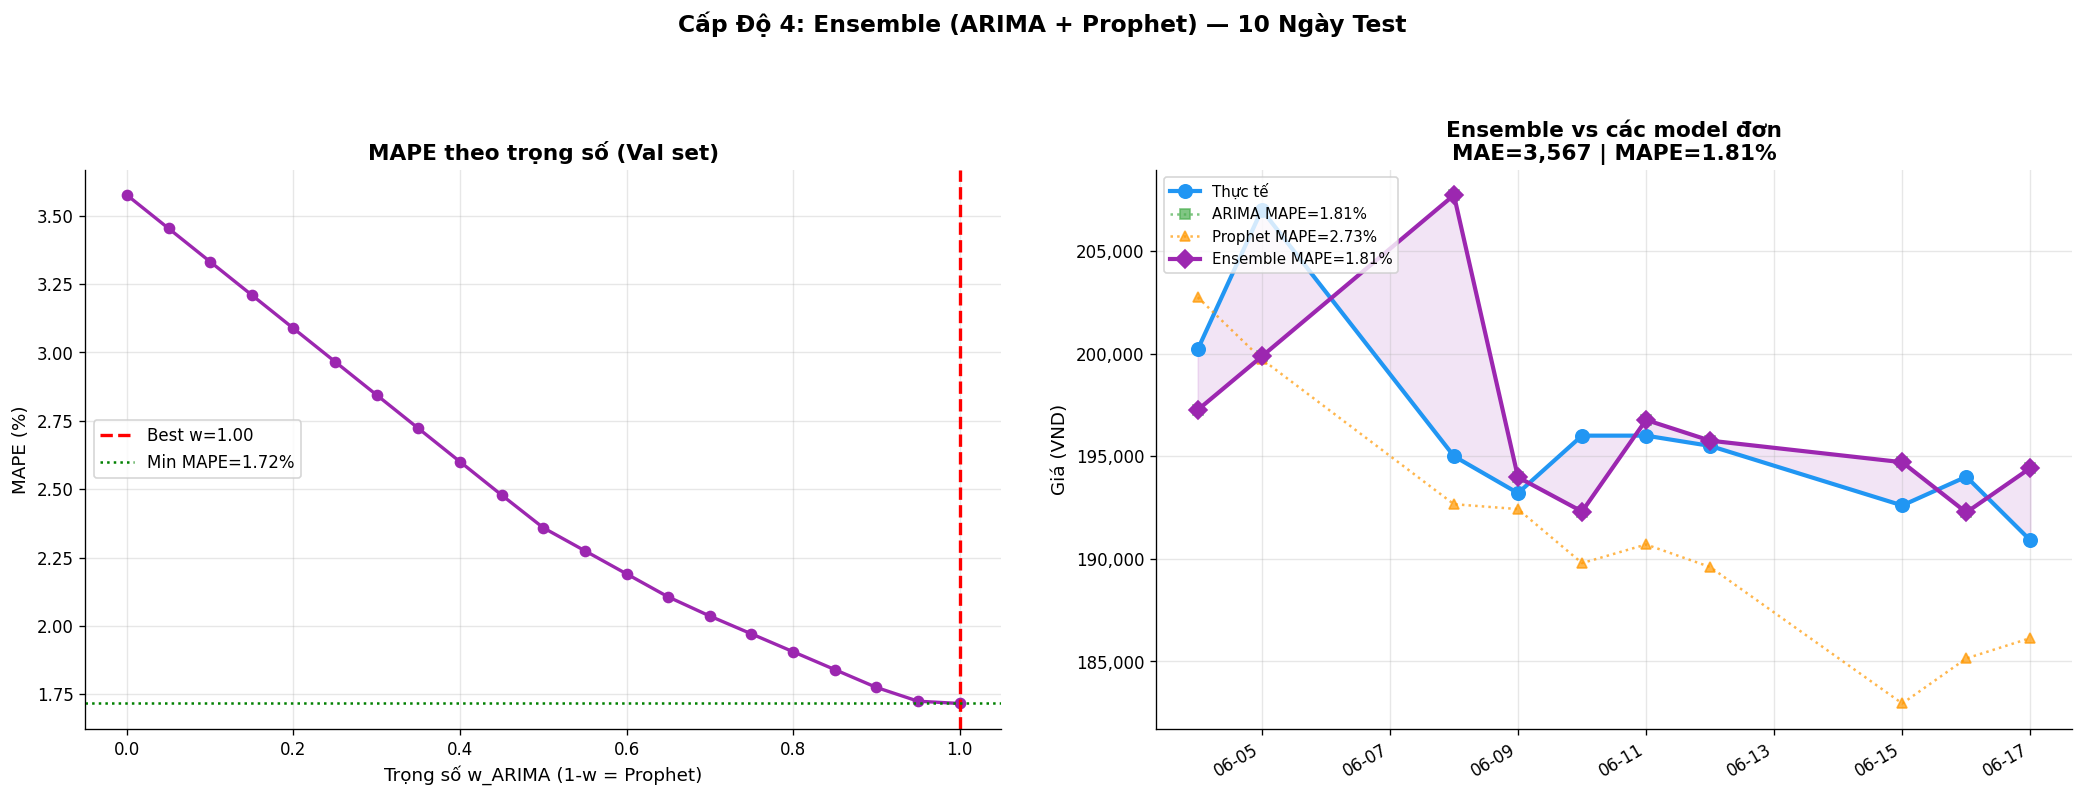

In [15]:
# Tối ưu trọng số w trên VAL set
print('Tối ưu trọng số Ensemble trên VAL set...')

# Val predictions: ARIMA
fc_arima_val = []
fc_prophet_val = []
for i in range(VAL_DAYS):
    w = df.iloc[:-(TEST_DAYS + VAL_DAYS - i)]
    try:
        fc_arima_val.append(float(ARIMA(w, order=(p_opt,d_opt,q_opt)).fit().forecast(1).iloc[0]))
    except:
        fc_arima_val.append(w.iloc[-1])
    m_pv = Prophet(changepoint_prior_scale=0.05, seasonality_mode='multiplicative',
                   daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
    m_pv.fit(make_prophet_df(w))
    fut_v = m_pv.make_future_dataframe(periods=1, freq='B')
    fc_prophet_val.append(float(m_pv.predict(fut_v)['yhat'].iloc[-1]))
    if i % 3 == 0: print(f'  Val bước {i+1}/{VAL_DAYS}')

# Sweep w
weights = np.arange(0, 1.05, 0.05)
mapes_val = []
for w_a in weights:
    ens = w_a * np.array(fc_arima_val) + (1 - w_a) * np.array(fc_prophet_val)
    mapes_val.append(mape_fn(val.values, ens))

best_w = weights[np.argmin(mapes_val)]
print(f'✓ Trọng số tốt nhất: w_ARIMA={best_w:.2f}, w_Prophet={1-best_w:.2f}  Val-MAPE={min(mapes_val):.2f}%')

# Ensemble trên TEST
pred_ensemble = pd.Series(
    best_w * preds['ARIMA'].values + (1 - best_w) * pred_prophet.values,
    index=test.index
)
m_ens = metrics_fn(test.values, pred_ensemble.values)
all_metrics[f'Ensemble(w={best_w:.2f})'] = m_ens
print_comparison_table(test, pred_ensemble, f'Ensemble ARIMA×{best_w:.2f} + Prophet×{1-best_w:.2f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Cấp Độ 4: Ensemble (ARIMA + Prophet) — 10 Ngày Test', fontsize=14, fontweight='bold')

ax1 = axes[0]
ax1.plot(weights, mapes_val, 'o-', color='#9C27B0', lw=2, ms=6)
ax1.axvline(best_w, color='r', ls='--', lw=2, label=f'Best w={best_w:.2f}')
ax1.axhline(min(mapes_val), color='g', ls=':', lw=1.5, label=f'Min MAPE={min(mapes_val):.2f}%')
ax1.set_xlabel('Trọng số w_ARIMA (1-w = Prophet)')
ax1.set_ylabel('MAPE (%)')
ax1.set_title('MAPE theo trọng số (Val set)', fontweight='bold')
ax1.legend()

ax2 = axes[1]
ax2.plot(test.index, test.values,          'o-', color='#2196F3', lw=2.5, ms=8, label='Thực tế')
ax2.plot(test.index, preds['ARIMA'].values,'s:', color='#4CAF50', lw=1.5, ms=6, alpha=0.7,
         label=f'ARIMA MAPE={metrics["ARIMA"]["MAPE"]:.2f}%')
ax2.plot(test.index, pred_prophet.values,  '^:', color='#FF9800', lw=1.5, ms=6, alpha=0.7,
         label=f'Prophet MAPE={m_prophet["MAPE"]:.2f}%')
ax2.plot(test.index, pred_ensemble.values, 'D-', color='#9C27B0', lw=2.5, ms=8,
         label=f'Ensemble MAPE={m_ens["MAPE"]:.2f}%')
ax2.fill_between(test.index, test.values, pred_ensemble.values, alpha=0.12, color='#9C27B0')
ax2.set_title(f'Ensemble vs các model đơn\nMAE={fmt_vnd(m_ens["MAE"])} | MAPE={m_ens["MAPE"]:.2f}%', fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.legend(fontsize=9, loc='upper left')
ax2.set_ylabel('Giá (VND)')

plt.tight_layout(pad=3.0)
plt.savefig('10_ensemble.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Cấp Độ 5 — ARIMA trên Log Returns

Grid search ARIMA trên log returns...


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

✓ Tốt nhất log returns: ARIMA(1,0,0)


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\


  [ARIMA-LogRet(1,0,0)] BẢNG SO SÁNH GIÁ THỰC TẾ vs DỰ ĐOÁN
  Ngày          Thực tế (VND)  Dự đoán (VND)   Chênh lệch  Sai số %
  ------------ -------------- -------------- ------------ ---------
  2026-06-04          200,200        197,253       -2,947    -1.47%
  2026-06-05          207,000        201,342       -5,658    -2.73%
  2026-06-08          195,000        208,828      +13,828    +7.09%
  2026-06-09          193,200        194,031         +831    +0.43%
  2026-06-10          196,000        193,649       -2,351    -1.20%
  2026-06-11          196,000        197,137       +1,137    +0.58%
  2026-06-12          195,500        196,723       +1,223    +0.63%
  2026-06-15          192,600        196,147       +3,547    +1.84%
  2026-06-16          194,000        192,882       -1,118    -0.58%
  2026-06-17          190,900        194,914       +4,014    +2.10%
───────────────────────────────────────────────────────────────────────────
  MAE=3,665 VND  |  RMSE=5,204 VND  |  MAPE=1.8

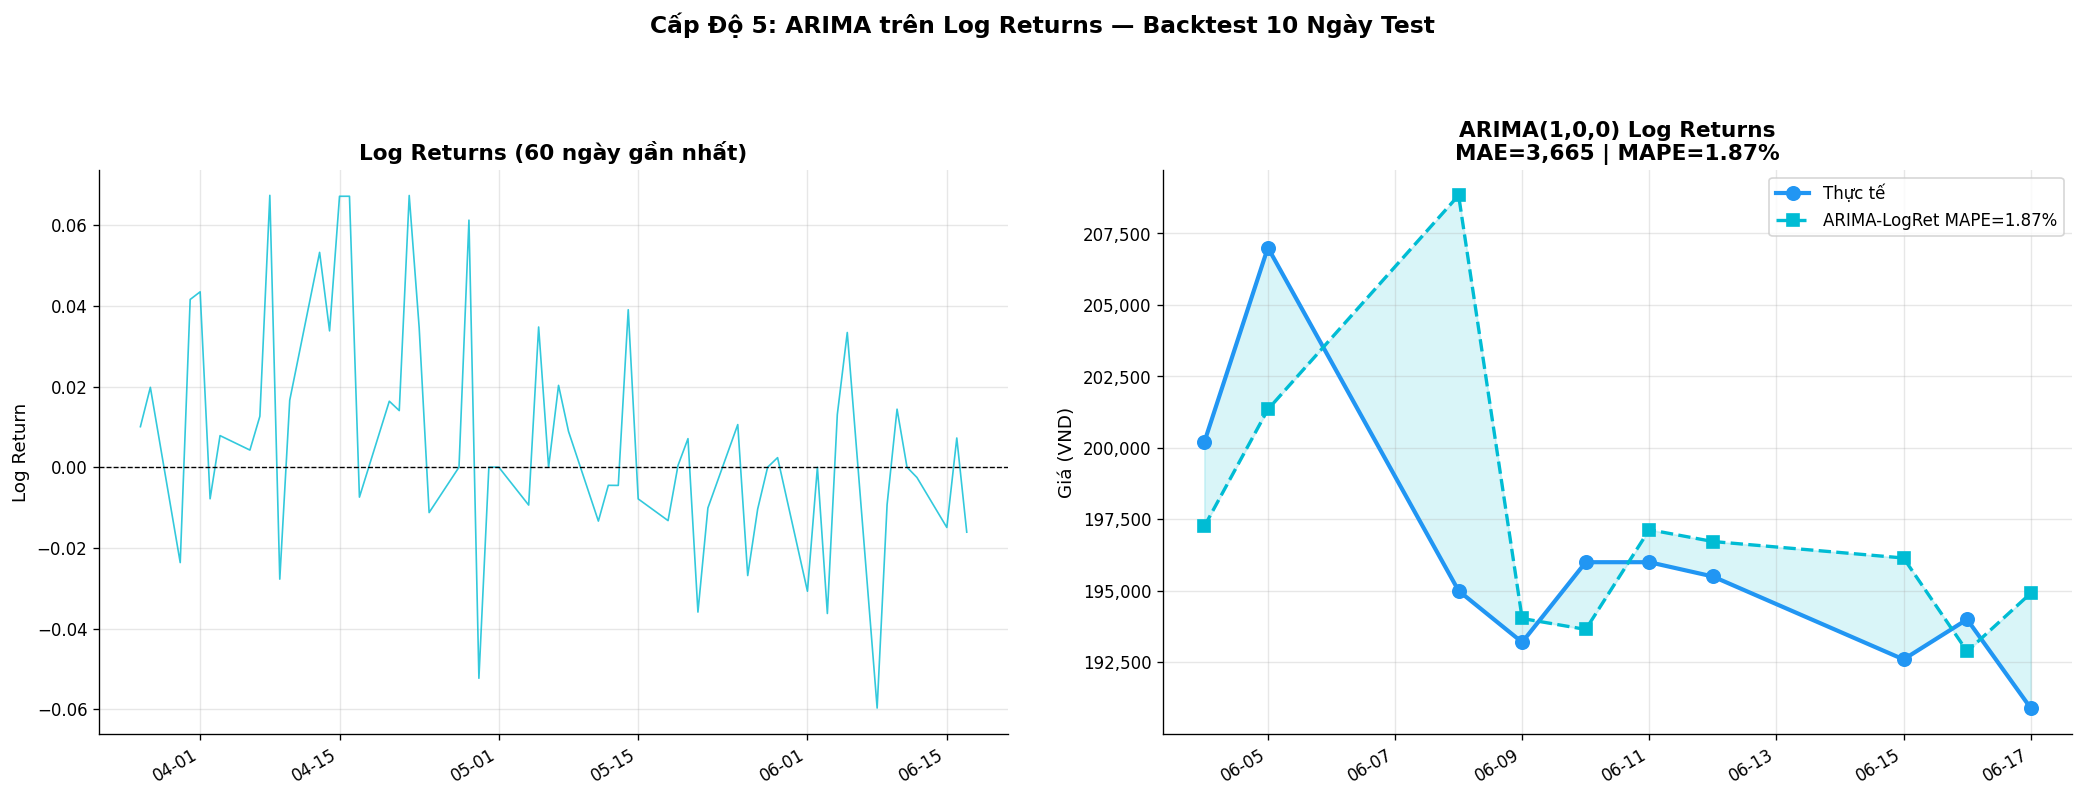

In [16]:
log_returns = np.log(df / df.shift(1)).dropna()
lr_train = log_returns.iloc[:-(TEST_DAYS + VAL_DAYS)]
lr_test_start_idx = len(log_returns) - TEST_DAYS

# Grid search AIC trên log returns (train)
print('Grid search ARIMA trên log returns...')
best_aic_lr, best_order_lr = np.inf, (1, 0, 1)
for p in range(P_MAX+1):
    for q in range(Q_MAX+1):
        if p == 0 and q == 0: continue
        try:
            m = ARIMA(lr_train, order=(p, 0, q)).fit()
            if m.aic < best_aic_lr:
                best_aic_lr, best_order_lr = m.aic, (p, 0, q)
        except:
            pass

p_lr, d_lr, q_lr = best_order_lr
print(f'✓ Tốt nhất log returns: ARIMA({p_lr},{d_lr},{q_lr})')

# Rolling backtest: predict log return → convert to price
fc_lr_prices = []
for i in range(TEST_DAYS):
    lr_window = log_returns.iloc[:lr_test_start_idx - TEST_DAYS + i + len(log_returns) - len(df) + 1]
    lr_w = log_returns.iloc[:-(TEST_DAYS - i)]
    prev_price = df.iloc[-(TEST_DAYS - i) - 1]
    try:
        m_lr = ARIMA(lr_w, order=(p_lr, d_lr, q_lr)).fit()
        pred_lr = float(m_lr.forecast(1).iloc[0])
        fc_lr_prices.append(prev_price * np.exp(pred_lr))
    except:
        fc_lr_prices.append(prev_price)

pred_log_ret = pd.Series(fc_lr_prices, index=test.index)
m_lr_res = metrics_fn(test.values, pred_log_ret.values)
all_metrics[f'ARIMA-LogRet({p_lr},{d_lr},{q_lr})'] = m_lr_res
print_comparison_table(test, pred_log_ret, f'ARIMA-LogRet({p_lr},{d_lr},{q_lr})')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Cấp Độ 5: ARIMA trên Log Returns — Backtest 10 Ngày Test', fontsize=14, fontweight='bold')

axes[0].plot(log_returns.index[-60:], log_returns.values[-60:], color='#00BCD4', lw=1.0, alpha=0.8)
axes[0].axhline(0, color='k', lw=0.8, ls='--')
axes[0].set_title('Log Returns (60 ngày gần nhất)', fontweight='bold')
axes[0].set_ylabel('Log Return')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

axes[1].plot(test.index, test.values,          'o-', color='#2196F3', lw=2.5, ms=8, label='Thực tế')
axes[1].plot(test.index, pred_log_ret.values,  's--', color='#00BCD4', lw=2.0, ms=7,
             label=f'ARIMA-LogRet MAPE={m_lr_res["MAPE"]:.2f}%')
axes[1].fill_between(test.index, test.values, pred_log_ret.values, alpha=0.15, color='#00BCD4')
axes[1].set_title(f'ARIMA({p_lr},{d_lr},{q_lr}) Log Returns\nMAE={fmt_vnd(m_lr_res["MAE"])} | MAPE={m_lr_res["MAPE"]:.2f}%', fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[1].legend(fontsize=10)
axes[1].set_ylabel('Giá (VND)')

plt.tight_layout(pad=3.0)
plt.savefig('11_log_returns.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Cấp Độ 6 — GARCH(1,1)

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 VIC.VN   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1143.43
Distribution:                  Normal   AIC:                           2294.86
Method:            Maximum Likelihood   BIC:                           2311.73
                                        No. Observations:                  502
Date:                Wed, Jun 17 2026   Df Residuals:                      501
Time:                        14:27:02   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.0769      0.107      0.719      0.472 [ -0.133,  0.28

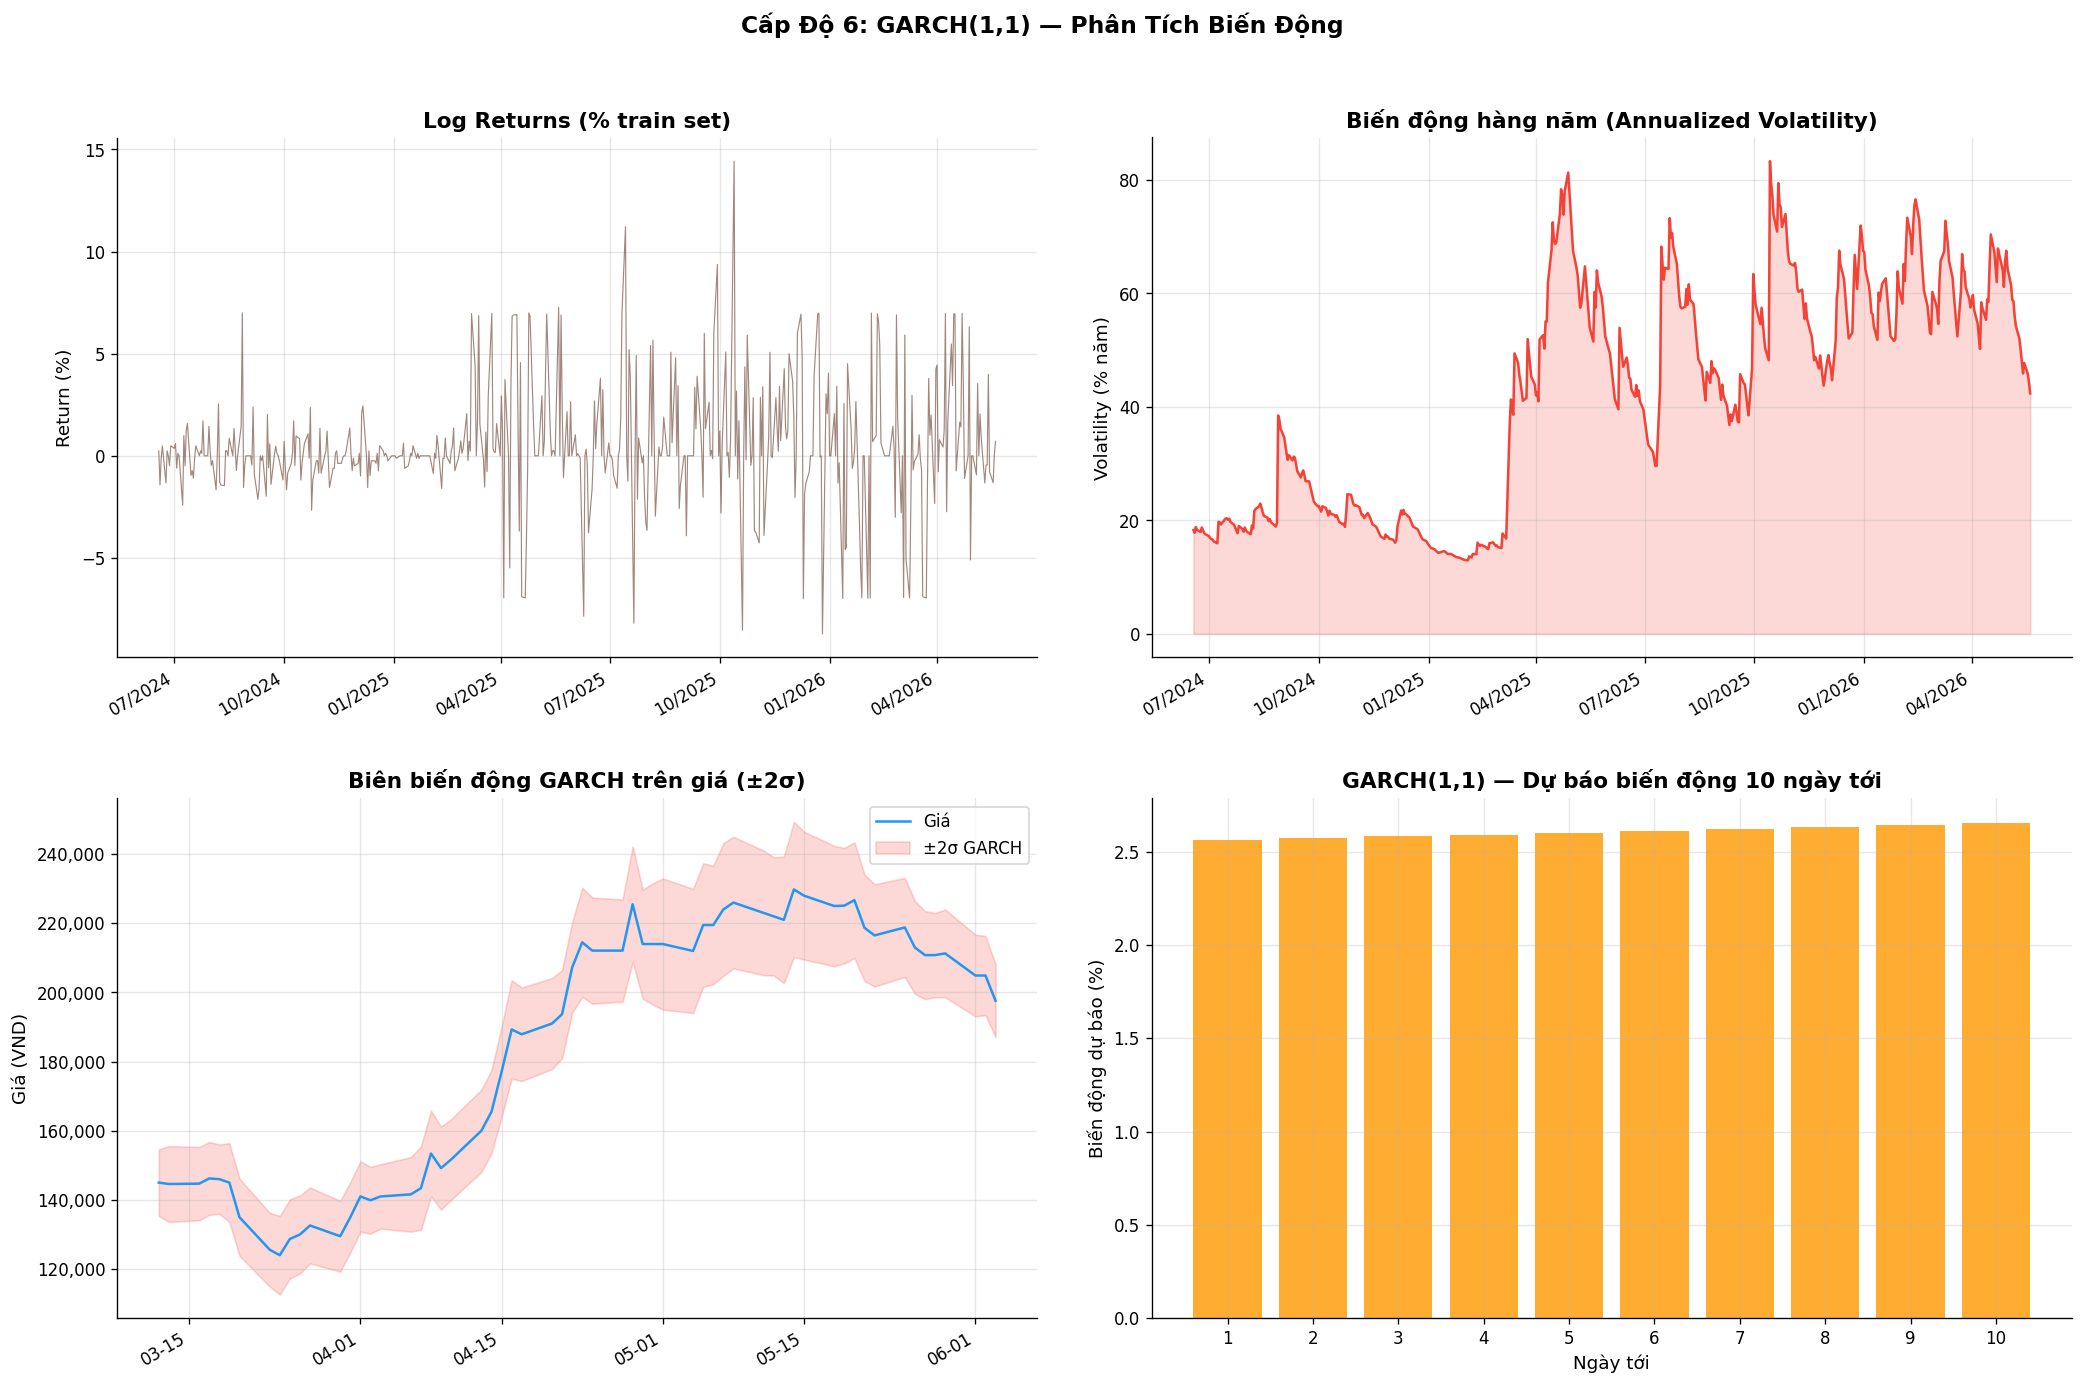

In [17]:
lr_pct_train = (np.exp(lr_train) - 1) * 100
lr_pct_full  = (np.exp(log_returns) - 1) * 100

garch = arch_model(lr_pct_train, vol='Garch', p=1, q=1, dist='normal').fit(disp='off')
print(garch.summary())

# Conditional volatility
cond_vol = garch.conditional_volatility
annualized_vol = cond_vol * np.sqrt(252)

# GARCH forecast (vol forecast, convert to price range)
garch_fc = garch.forecast(horizon=FORECAST, reindex=False)
fc_vol   = np.sqrt(garch_fc.variance.values[-1])
last_p   = df.iloc[-TEST_DAYS-1]
print(f'\nGARCH(1,1) — Dự báo biến động {FORECAST} ngày tới:')
print(f'  Ngày  | Biến động (%) | Upper (VND) | Lower (VND)')
for i, v in enumerate(fc_vol):
    up  = last_p * (1 + v/100)
    dn  = last_p * (1 - v/100)
    print(f'  +{i+1:2d}    |   {v:6.3f}%      | {fmt_vnd(up):>12} | {fmt_vnd(dn):>12}')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Cấp Độ 6: GARCH(1,1) — Phân Tích Biến Động', fontsize=14, fontweight='bold')

axes[0,0].plot(lr_pct_train.index, lr_pct_train.values, color='#795548', lw=0.7, alpha=0.7)
axes[0,0].set_title('Log Returns (% train set)', fontweight='bold')
axes[0,0].set_ylabel('Return (%)')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=30, ha='right')

axes[0,1].plot(cond_vol.index, annualized_vol.values, color='#F44336', lw=1.5)
axes[0,1].fill_between(cond_vol.index, annualized_vol.values, alpha=0.2, color='#F44336')
axes[0,1].set_title('Biến động hàng năm (Annualized Volatility)', fontweight='bold')
axes[0,1].set_ylabel('Volatility (% năm)')
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.setp(axes[0,1].xaxis.get_majorticklabels(), rotation=30, ha='right')

axes[1,0].plot(df.iloc[-(TEST_DAYS+60):-TEST_DAYS].index, df.iloc[-(TEST_DAYS+60):-TEST_DAYS].values,
               color='#2196F3', lw=1.5, label='Giá')
vol_tail = cond_vol.values[-60:] / 100 * df.iloc[-(TEST_DAYS+60):-TEST_DAYS].values
price_sub = df.iloc[-(TEST_DAYS+60):-TEST_DAYS]
axes[1,0].fill_between(price_sub.index,
                        price_sub.values - 2*vol_tail,
                        price_sub.values + 2*vol_tail,
                        alpha=0.2, color='#F44336', label='±2σ GARCH')
axes[1,0].set_title('Biên biến động GARCH trên giá (±2σ)', fontweight='bold')
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
axes[1,0].set_ylabel('Giá (VND)')
axes[1,0].legend()
axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=30, ha='right')

axes[1,1].bar(range(1, FORECAST+1), fc_vol, color='#FF9800', alpha=0.8)
axes[1,1].set_xlabel('Ngày tới')
axes[1,1].set_ylabel('Biến động dự báo (%)')
axes[1,1].set_title(f'GARCH(1,1) — Dự báo biến động {FORECAST} ngày tới', fontweight='bold')
axes[1,1].set_xticks(range(1, FORECAST+1))

plt.tight_layout(pad=3.0)
plt.savefig('12_garch.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Cấp Độ 7 — ARIMAX (VN-Index + USD/VND)

Tải VN-Index và USD/VND...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ^VNINDEX"}}}
$^VNINDEX: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['^VNINDEX']: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")


  ✓ VN-Index: 0 ngày
  ✓ USD/VND: 518 ngày


ValueError: x and y must have length at least 2.

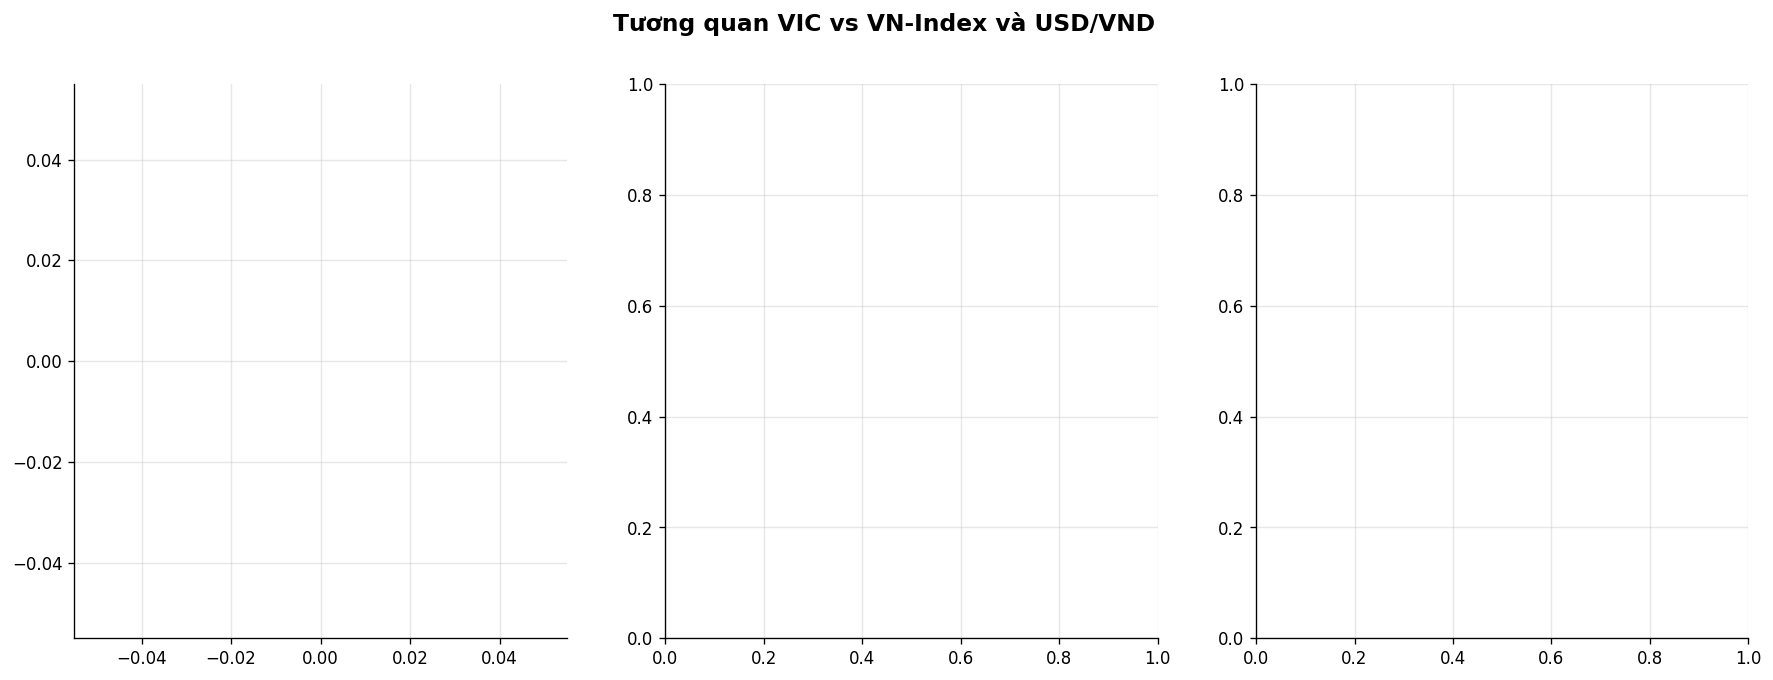

In [18]:
print('Tải VN-Index và USD/VND...')
tickers_exog = {'VN-Index': '^VNINDEX', 'USD/VND': 'USDVND=X'}
exog_frames = {}
for name_e, ticker_e in tickers_exog.items():
    try:
        raw_e = yf.download(ticker_e, period=PERIOD, auto_adjust=True, progress=False)
        exog_frames[name_e] = raw_e['Close'].squeeze()
        print(f'  ✓ {name_e}: {len(raw_e)} ngày')
    except Exception as ex:
        print(f'  ✗ {name_e}: {ex}')

if len(exog_frames) == 2:
    exog_df = pd.DataFrame(exog_frames).reindex(df.index).ffill().bfill()
    exog_z  = (exog_df - exog_df.mean()) / exog_df.std()

    # Correlation plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Tương quan VIC vs VN-Index và USD/VND', fontsize=14, fontweight='bold')

    for ax, (col, color) in zip(axes[:2], [('VN-Index','#4CAF50'), ('USD/VND','#E91E63')]):
        ax.scatter(exog_df[col], df.reindex(exog_df.index), alpha=0.3, color=color, s=15)
        r, p = stats.pearsonr(exog_df[col].dropna(), df.reindex(exog_df[col].dropna().index))
        ax.set_xlabel(col)
        ax.set_ylabel('VIC (VND)')
        ax.set_title(f'VIC vs {col}\nr={r:.3f}, p={p:.4f}', fontweight='bold')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p2: f'{x:,.0f}'))

    corr_m = pd.concat([df.rename('VIC'), exog_df], axis=1).corr()
    sns.heatmap(corr_m, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=axes[2],
                linewidths=0.5, annot_kws={'size': 11})
    axes[2].set_title('Heatmap tương quan', fontweight='bold')

    plt.tight_layout(pad=3.0)
    plt.savefig('13_correlation.png', dpi=120, bbox_inches='tight')
    plt.show()

    # ARIMAX rolling backtest
    print('ARIMAX rolling backtest 10 ngày...')
    fc_arimax = []
    for i in range(TEST_DAYS):
        n_end = -(TEST_DAYS - i) if i < TEST_DAYS else len(df)
        wd    = df.iloc[:n_end]
        wd_ex = exog_z.iloc[:n_end].values
        fc_ex = exog_z.iloc[n_end].values.reshape(1, -1) if abs(n_end) < len(df) else exog_z.iloc[-1].values.reshape(1,-1)
        try:
            m_ax = ARIMA(wd, order=(p_opt, d_opt, q_opt), exog=wd_ex).fit()
            fc_arimax.append(float(m_ax.forecast(1, exog=fc_ex).iloc[0]))
        except:
            fc_arimax.append(wd.iloc[-1])
        if i % 3 == 0: print(f'  Bước {i+1}/{TEST_DAYS}')

    pred_arimax = pd.Series(fc_arimax, index=test.index)
    m_arimax = metrics_fn(test.values, pred_arimax.values)
    all_metrics[f'ARIMAX({p_opt},{d_opt},{q_opt})'] = m_arimax
    print_comparison_table(test, pred_arimax, f'ARIMAX({p_opt},{d_opt},{q_opt})')

    fig, ax = plt.subplots(figsize=(16, 7))
    ax.plot(test.index, test.values,         'o-', color='#2196F3', lw=2.5, ms=8, label='Thực tế')
    ax.plot(test.index, preds['ARIMA'].values,'s:', color='#4CAF50', lw=1.8, ms=6, alpha=0.8,
            label=f'ARIMA MAPE={metrics["ARIMA"]["MAPE"]:.2f}%')
    ax.plot(test.index, pred_arimax.values,   'D-', color='#FF5722', lw=2.5, ms=8,
            label=f'ARIMAX MAPE={m_arimax["MAPE"]:.2f}%')
    ax.set_title(f'ARIMA vs ARIMAX — ARIMAX MAE={fmt_vnd(m_arimax["MAE"])} MAPE={m_arimax["MAPE"]:.2f}%', fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=10)
    ax.set_ylabel('Giá (VND)')
    plt.tight_layout(pad=3.0)
    plt.savefig('14_arimax.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Bỏ qua ARIMAX do không tải được exog data.')
    pred_arimax = None

## 11. So Sánh Toàn Diện — Tất Cả Mô Hình

In [ ]:
# Tổng hợp tất cả predictions — key phải khớp với all_metrics
all_preds = {
    'AR':    preds['AR'],
    'MA':    preds['MA'],
    'ARIMA': preds['ARIMA'],
    f'ARIMA-Optuna({best_p2},{best_d2},{best_q2})': pred_optuna,
    'Prophet': pred_prophet,
    f'Ensemble(w={best_w:.2f})': pred_ensemble,
    f'ARIMA-LogRet({p_lr},{d_lr},{q_lr})': pred_log_ret,
}
if pred_arimax is not None:
    all_preds[f'ARIMAX({p_opt},{d_opt},{q_opt})'] = pred_arimax

# Bảng tổng hợp metrics
print(f'\n{"═"*90}')
print(f'  BẢNG SO SÁNH TẤT CẢ MÔ HÌNH — 10 NGÀY TEST')
print(f'  ({test.index[0].date()} → {test.index[-1].date()})')
print(f'{"═"*90}')
print(f'  {"Mô hình":<40} {"MAE (VND)":>14} {"RMSE (VND)":>14} {"MAPE (%)":>10} {"Xếp hạng":>8}')
print(f'  {"-"*40} {"-"*14} {"-"*14} {"-"*10} {"-"*8}')

sorted_models = sorted(all_metrics.items(), key=lambda x: x[1]['MAPE'])
for rank, (name, m) in enumerate(sorted_models, 1):
    star = ' ★' if rank == 1 else ''
    print(f'  {name:<40} {fmt_vnd(m["MAE"]):>14} {fmt_vnd(m["RMSE"]):>14} {m["MAPE"]:>9.2f}%  #{rank}{star}')
print(f'{"═"*90}')
best_name, best_m = sorted_models[0]
print(f'\n  ★ MÔ HÌNH TỐT NHẤT: {best_name}')
print(f'    MAE={fmt_vnd(best_m["MAE"])} VND  |  RMSE={fmt_vnd(best_m["RMSE"])} VND  |  MAPE={best_m["MAPE"]:.2f}%')

In [ ]:
# ── BẢNG GIÁ THỰC TẾ vs DỰ ĐOÁN — TẤT CẢ MODEL ──────────────────────
print(f'\n{"═"*120}')
print(f'  BẢNG GIÁ THỰC TẾ vs DỰ ĐOÁN CỦA TẤT CẢ MÔ HÌNH')
print(f'{"═"*120}')

model_names_short = list(all_preds.keys())
header = f'  {"Ngày":<12}  {"Thực tế":>12}'
for n in model_names_short:
    header += f'  {n[:14]:>14}'
print(header)
print(f'  {"-"*12}  {"-"*12}' + '  ' + '  '.join(['-'*14]*len(model_names_short)))

for d in test.index:
    actual = test[d]
    row = f'  {str(d.date()):<12}  {fmt_vnd(actual):>12}'
    for n in model_names_short:
        v = all_preds[n][d]
        row += f'  {fmt_vnd(v):>14}'
    print(row)

print(f'  {"-"*12}  {"-"*12}' + '  ' + '  '.join(['-'*14]*len(model_names_short)))
mrow = f'  {"MAPE (%)":<12}  {"─":>12}'
for n in model_names_short:
    mrow += f'  {all_metrics.get(n, {}).get("MAPE", 0):>13.2f}%'
print(mrow)
print(f'{"═"*120}')

In [ ]:
# ── Dashboard 1: Metrics Comparison ────────────────────────────────────
model_keys  = [n for n, _ in sorted_models]
maes   = [all_metrics[n]['MAE']  for n in model_keys]
rmses  = [all_metrics[n]['RMSE'] for n in model_keys]
mapes  = [all_metrics[n]['MAPE'] for n in model_keys]
colors_bar  = [COLORS[i % len(COLORS)] for i in range(len(model_keys))]
short_names = [n[:20] for n in model_keys]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Dashboard Metrics — Tất Cả Mô Hình (Sắp xếp theo MAPE tăng dần)',
             fontsize=14, fontweight='bold')

for ax, vals, label, unit in zip(
    axes,
    [maes, rmses, mapes],
    ['MAE', 'RMSE', 'MAPE'],
    ['VND', 'VND', '%']
):
    bars = ax.barh(short_names, vals, color=colors_bar, alpha=0.85)
    if unit == 'VND':
        labels_txt = [f'{v:,.0f}' for v in vals]
    else:
        labels_txt = [f'{v:.2f}%' for v in vals]
    ax.bar_label(bars, labels=labels_txt, padding=5, fontsize=9)
    ax.set_xlabel(f'{label} ({unit})')
    ax.set_title(f'{label} ({unit})', fontweight='bold')
    ax.invert_yaxis()
    if unit == 'VND':
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

plt.tight_layout(pad=3.0)
plt.savefig('15_metrics_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Dashboard 2: Tất cả model overlay trên 10 ngày test ────────────────
n_models = len(all_preds)
n_cols   = 2
n_rows   = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5 + 1))
fig.suptitle(f'Giá Thực Tế vs Dự Đoán — Từng Mô Hình ({test.index[0].date()} → {test.index[-1].date()})',
             fontsize=14, fontweight='bold', y=1.01)
axes_flat = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()

for idx, (name, pred) in enumerate(all_preds.items()):
    ax = axes_flat[idx]
    m  = all_metrics.get(name, {})
    color = COLORS[idx % len(COLORS)]

    ax.plot(test.index, test.values, 'o-', color='#2196F3', lw=2.5, ms=7, label='Thực tế', zorder=5)
    ax.plot(test.index, pred.values, 's--', color=color, lw=2.0, ms=7, label=f'{name[:18]}')
    ax.fill_between(test.index, test.values, pred.values, alpha=0.12, color=color)

    for d, v_real, v_pred in zip(test.index, test.values, pred.values):
        ax.annotate(f'{v_real/1000:.0f}K', (d, v_real), textcoords='offset points',
                    xytext=(0, 7), ha='center', fontsize=7, color='#2196F3')
        ax.annotate(f'{v_pred/1000:.0f}K', (d, v_pred), textcoords='offset points',
                    xytext=(0, -13), ha='center', fontsize=7, color=color)

    ax.set_title(f'{name[:25]}\nMAE={fmt_vnd(m.get("MAE",0))} | MAPE={m.get("MAPE",0):.2f}%',
                 fontweight='bold', fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_ylabel('Giá (VND)', fontsize=9)

for idx in range(len(all_preds), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout(pad=3.0, h_pad=4.0, w_pad=3.0)
plt.savefig('16_all_models_overlay.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Dashboard 3: Radar Chart + Ranking Table ─────────────────────────
from matplotlib.patches import FancyBboxPatch

fig = plt.figure(figsize=(22, 10))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.4)
fig.suptitle('Đánh Giá Tổng Hợp — Radar Chart & Bảng Xếp Hạng', fontsize=14, fontweight='bold')

# Radar
categories = ['MAE\n(thấp hơn tốt)', 'RMSE\n(thấp hơn tốt)', 'MAPE\n(thấp hơn tốt)']
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

ax_radar = fig.add_subplot(gs[0], polar=True)
# Normalize scores (lower is better → invert)
all_mae  = np.array([all_metrics[n]['MAE']  for n in model_keys])
all_rmse = np.array([all_metrics[n]['RMSE'] for n in model_keys])
all_mape = np.array([all_metrics[n]['MAPE'] for n in model_keys])

def norm_inv(arr):
    mn, mx = arr.min(), arr.max()
    if mx == mn: return np.ones_like(arr)
    return 1 - (arr - mn) / (mx - mn)

scores = np.column_stack([norm_inv(all_mae), norm_inv(all_rmse), norm_inv(all_mape)])
for i, (name, sc) in enumerate(zip(model_keys, scores)):
    vals = sc.tolist() + sc[:1].tolist()
    color = COLORS[i % len(COLORS)]
    ax_radar.plot(angles, vals, 'o-', lw=1.5, color=color, label=name[:20], ms=4)
    ax_radar.fill(angles, vals, alpha=0.05, color=color)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_radar.set_yticklabels(['25%','50%','75%','100%'], fontsize=7)
ax_radar.set_title('Radar Chart\n(điểm cao = tốt hơn)', fontweight='bold', pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)

# Ranking table
ax_tbl = fig.add_subplot(gs[1])
ax_tbl.axis('off')
tbl_data = []
for rank, (name, m) in enumerate(sorted_models, 1):
    tbl_data.append([f'#{rank}', name[:22], f'{fmt_vnd(m["MAE"])}',
                     f'{fmt_vnd(m["RMSE"])}', f'{m["MAPE"]:.2f}%'])
cols = ['#', 'Mô hình', 'MAE (VND)', 'RMSE (VND)', 'MAPE']
tbl = ax_tbl.table(cellText=tbl_data, colLabels=cols,
                   loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 2.0)
for j in range(len(cols)):
    tbl[0, j].set_facecolor('#1565C0')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
tbl[1, 0].set_facecolor('#FFF9C4')
for j in range(len(cols)):
    tbl[1, j].set_facecolor('#FFF9C4')
ax_tbl.set_title('Bảng Xếp Hạng (theo MAPE tăng dần)', fontweight='bold', fontsize=12, pad=20)

plt.savefig('17_final_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n{"═"*55}')
print(f'  TỔNG KẾT CUỐI')
print(f'{"═"*55}')
print(f'  Giai đoạn test: {test.index[0].date()} → {test.index[-1].date()}')
print(f'  Số ngày test:   {TEST_DAYS} ngày giao dịch')
print(f'  Số mô hình:     {len(all_metrics)}')
print(f'  Model tốt nhất: {sorted_models[0][0]}')
print(f'  MAPE tốt nhất:  {sorted_models[0][1]["MAPE"]:.2f}%')
print(f'  MAPE tệ nhất:   {sorted_models[-1][1]["MAPE"]:.2f}%')
print(f'{"═"*55}')